# Regression-based error attribution (Zhong et al. 2023)

Follows Zhong et al. (2023, Sci. Adv.): source-region (africa, amazon)
Fig. 3-style AAOD error decomposition. African outflow AAOD is a meta-model
prediction target (Supplementary Text 2), not a load/emission lifetime
decomposition.

Key equations:
- `AAOD = E * tau * MAC`
- `1/tau = A + alpha * Pr + beta * AE`
- `MAC = F * SSA` (+ intercept if `INTERCEPT_0` is False)
- `E_C = AAOD_obs / (tau_C * MAC_C)`
- Outflow: `AAOD_out = a*(E*tau*MAC) + b*(E*tau) + c*MAC + d`

Configuration flags (defaults):
- `INTERCEPT_0 = False` — OLS with intercept; `True` forces through origin
- `POLDER_HOMOGENIZE = True` — Zhong et al. regional AAOD homogenization
- Amazon SOA always included via paper ~52% fraction of total OA


## Notes and caveats

- The model monthly pickle is regenerated by `py/get_data.py` in `Data/var_files/original/monthly/`.
- This notebook loads from the legacy master pickle by default; set `USE_PICKLE = False` to load from NetCDF files under `Data/AP3_processed_monthly/` instead.
- POLDER-GRASP 3-hourly collocated data are aggregated to monthly and then seasonal regional means.
- GPCP monthly precipitation is used for observed precipitation.
- Model precipitation files have mixed units; a unit-normalization step converts everything to mm day⁻¹ and applies a sanity check for mislabeled g m⁻² s⁻¹ files.
- Some models lack `abs550aer` or spectral AOD variables and are excluded from the MAC/SSA/AE regressions.
- Lifetime (`load / emission`) can contain very large or non-finite values; a configurable filter removes these before the regression.

In [1]:
import sys
import os
from pathlib import Path
import pickle
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import linregress
from xarray.coding.times import decode_cf_datetime

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Project paths
try:
    project_root = Path(__file__).resolve().parent.parent
except NameError:
    project_root = Path('/scistor/guest/gbb083/AeroCom')
py_dir = project_root / 'py'
if str(py_dir) not in sys.path:
    sys.path.insert(0, str(py_dir))

import functions
import cameo_toolbox as ct
import aerocom_data

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
EXCLUDE_MODELS = []  # e.g. ['GEOS-i33p2-met2010_AP3-CTRL']

# Derived variables computed after regional/temporal aggregation.
DERIVED_VAR_AFTER_AGG = ['lifetime','lifetime_BC_OA']

# Lifetime outlier filtering at grid-cell level (disabled when lifetime is
# computed after aggregation).
LIFETIME_MAX_DAYS = 365
LIFETIME_MIN_DAYS = 1e-3
if any(v in DERIVED_VAR_AFTER_AGG for v in ('lifetime', 'lifetime_BC_OA')):
    LIFETIME_MAX_DAYS = 365
    LIFETIME_MIN_DAYS = 1e-3

# Post-aggregation lifetime (load_BC_OA / emi_BC_OA) outlier filtering.
#
# This ratio is a box-budget estimator (Zhong et al. 2023 definition: column
# burden / emission) and can explode when a model's *local* emission in the
# source box is tiny relative to load advected in from outside the box (i.e.
# a transport-dominated, not physically slow-removal, situation). In this
# ensemble a handful of models (e.g. CAM5_CTRL2016, EC-Earth3-AerChem,
# TM5-met2010_AP3-CTRL2019, GFDL-AM4-met2010_AP3-CTRL) show seasonal-mean
# BC+OA lifetimes of 40-130 days in one or more source regions, while every
# other model - and the full model ensemble shown in Zhong et al. 2023 Fig.
# S3 - stays within roughly 1.5-8 days (1/lifetime ~ 0.1-0.4 d^-1). These
# outliers are calculation artifacts, not evidence of genuinely long-lived
# aerosol, so they are excluded here rather than allowed to dominate the
# 1/tau regression and the AAOD error decomposition.
POST_AGG_LIFETIME_MAX_DAYS = 15.0
POST_AGG_LIFETIME_MIN_DAYS = 0.3

SAVE_FIGURE = False
USE_PICKLE = False

# MAC–SSA regression:
#   INTERCEPT_0 = False -> MAC = F * SSA + intercept  (OLS; default)
#   INTERCEPT_0 = True  -> MAC = F * SSA              (through origin)
INTERCEPT_0 = False

# Zhong et al. POLDER-GRASP homogenization of regional AAOD used for E_C.
POLDER_HOMOGENIZE = True

# Homogenize regional SSA_obs the same way as AAOD_obs (item 2): fit
# sampled = a * regional + b from models, then invert with the raw
# POLDER-sampled SSA mean.
SSA_POLDER_HOMOGENIZE = True

# Amazon SOA: no dedicated emisoa variable in AP3_processed_monthly.
# Zhong et al. (2023) estimate SOA ≈ 52% of total OA over the Amazon.
# Treat model emioa as primary OA and scale so SOA/(POA+SOA) = AMAZON_SOA_FRACTION.
AMAZON_SOA_FRACTION = 0.52
INCLUDE_AMAZON_SOA = True  # always on for the main workflow; toggle only for debugging

REGIONS = {
    # 'global': {
    #     'surface_type': 'all',
    #     'lon_range': (0, 360), 'lat_range': (-90, 90),
    #     'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    # },
    'africa': {
        'surface_type': 'land',
        'lon_range': (15, 37), 'lat_range': (-15, 0),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': False,
    },
    'amazon': {
        'surface_type': 'land',
        'lon_range': (287, 317), 'lat_range': (-17, -3),
        'time_slice': ('2010-07-01', '2010-10-31'), 'edge_weighted': False,
    },
    # lon_range=(350, 8) is a longitude wraparound spanning
    # 350-360 deg + 0-8 deg, i.e. -10 deg E to 8 deg E: the South
    # Atlantic outflow region just west of Southern Africa. This is
    # geographically correct (verified against Zhong et al. 2023); only
    # the plotting helper (ct.fake_uba_map) needed a wraparound-aware
    # fix, applied in py/cameo_toolbox.py.
    'outflow_af': {
        'surface_type': 'ocean',
        'lon_range': (350, 15), 'lat_range': (-15, 0),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': True,
    },
    # The actual 2010 Russian Mega-Fire Event (Western/European Russia)
    'west_russia': {
        'surface_type': 'land',
        'lon_range': (33, 52), 'lat_range': (51, 60),
        'time_slice': ('2010-07-15', '2010-09-10'), 'edge_weighted': False,
    },
    'boreal_na_west': {
        'surface_type': 'land',
        'lon_range': (242, 258), 'lat_range': (52, 63),
        'time_slice': ('2010-06-15', '2010-08-31'), 'edge_weighted': False,
    }
}
# Source regions used for the main Fig. 3-style decomposition.
SOURCE_REGIONS = ['africa', 'amazon', 'west_russia', 'boreal_na_west']
OUTFLOW_REGION = 'outflow_af'
OUTFLOW_SOURCE = 'africa'

# Shared per-region color palette (used across all plots in this notebook).
REGION_COLORS = {
    'africa': '#ff7f0e', 'amazon': '#2ca02c', 'outflow_af': '#9467bd',
    'west_russia': '#8c564b', 'boreal_na_west': '#1f77b4',
}

PAPER_DECOMP = {
    'amazon': {'pct_E':19,'pct_tau':20,'pct_MAC': 47},
    'africa': {'pct_E': 40, 'pct_tau': 15,'pct_MAC': 31 },
}

print('\n--- Active configuration ---')
print(f'  INTERCEPT_0          = {INTERCEPT_0}  '
      f"({'through origin' if INTERCEPT_0 else 'OLS with intercept'})")
print(f'  POLDER_HOMOGENIZE    = {POLDER_HOMOGENIZE}')
print(f'  SSA_POLDER_HOMOGENIZE= {SSA_POLDER_HOMOGENIZE}')
print(f'  INCLUDE_AMAZON_SOA   = {INCLUDE_AMAZON_SOA}  '
      f'(fraction={AMAZON_SOA_FRACTION:.0%} of total OA)')
print(f'  EXCLUDE_MODELS      = {EXCLUDE_MODELS}')
print(f'  DERIVED_VAR_AFTER_AGG= {DERIVED_VAR_AFTER_AGG}')
print(f'  SAVE_FIGURE          = {SAVE_FIGURE}')


Project root: /scistor/guest/gbb083/AeroCom
Python dir:   /scistor/guest/gbb083/AeroCom/py

--- Active configuration ---
  INTERCEPT_0          = False  (OLS with intercept)
  POLDER_HOMOGENIZE    = True
  SSA_POLDER_HOMOGENIZE= True
  INCLUDE_AMAZON_SOA   = True  (fraction=52% of total OA)
  EXCLUDE_MODELS      = []
  DERIVED_VAR_AFTER_AGG= ['lifetime', 'lifetime_BC_OA']
  SAVE_FIGURE          = False


## Load monthly model data


In [2]:
VARIABLES = [
    'abs550aer', 'depbc', 'depdust', 'depoa', 'depso2', 'depso4', 'depss',
    'emibc', 'emidust', 'emioa', 'emiso2', 'emiss', 'loadbc', 'loaddust',
    'loadoa', 'loadso2', 'loadso4', 'loadss', 'od440aer', 'od550aer',
    'od870aer', 'od865aer', 'od550bc', 'od550dust', 'od550oa', 'od550so4', 'od550ss',
    'precip'
]

if USE_PICKLE:
    monthly_pickle = project_root / 'Data' / 'var_files' / 'original' / 'monthly' / 'monthly_aerocom_data.pickle'
    print(f'Loading monthly pickle: {monthly_pickle}')
    with open(monthly_pickle, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print('Loading monthly data from processed NetCDF files...')
    raw_data = aerocom_data.load_monthly_data_from_netcdf(
        output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
        variables=VARIABLES,
    )

# Apply model exclusion list before any processing
missing_excluded = [m for m in EXCLUDE_MODELS if m not in raw_data]
if missing_excluded:
    print(f'Warning: excluded models not found in data: {missing_excluded}')
models = sorted([m for m in raw_data.keys() if m not in EXCLUDE_MODELS])
actually_excluded = [m for m in EXCLUDE_MODELS if m in raw_data]
print(f'Number of models: {len(models)} (excluded {len(actually_excluded)}: {actually_excluded})')

# Document SOA availability in processed NetCDF
_available_vars = sorted({
    p.name for p in (project_root / 'Data' / 'AP3_processed_monthly').iterdir()
    if p.is_dir()
}) if (project_root / 'Data' / 'AP3_processed_monthly').exists() else []
_soa_like = [v for v in _available_vars if 'soa' in v.lower() or 'seco' in v.lower()]
print(f'Processed monthly variables: {len(_available_vars)} directories')
if _soa_like:
    print(f'  Found SOA-like directories: {_soa_like}')
else:
    print('  No dedicated SOA / secondary-OA emission directory found; '
          f'using Amazon SOA fraction approximation ({AMAZON_SOA_FRACTION:.0%}).')


Loading monthly data from processed NetCDF files...
Loaded 586 NetCDF files for 29 models from /scistor/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Number of models: 29 (excluded 0: [])
Processed monthly variables: 29 directories
  No dedicated SOA / secondary-OA emission directory found; using Amazon SOA fraction approximation (52%).


## Normalize time and build combined variables


In [3]:
def normalize_dataset_time(ds, var_hint=None):
    """Normalize time coordinate of a dataset to first-of-month.

    Delegates to the module implementation, which handles cftime, 365_day
    calendars, bogus units, and trailing fill values.
    """
    return aerocom_data.normalize_dataset_time(ds, var_hint=var_hint, year=2010)


def sum_datasets(model_data, keys, out_name):
    """Sum a list of variables (Datasets) into a new Dataset, skipping missing ones."""
    dsets = [model_data[k] for k in keys if model_data.get(k) is not None]
    if not dsets:
        return None
    arrays = [d[list(d.data_vars)[0]] for d in dsets]
    total = arrays[0].copy()
    for a in arrays[1:]:
        total = total + a
    return total.to_dataset(name=out_name)


def normalize_precipitation_units(precip_ds):
    """Convert model precipitation to mm day^-1.

    Handles kg/m2/s, g/m2/s, and the typo 'km m-2 s-1' seen in ECHAM6.3-HAM2.3.
    Also applies a sanity check: if the global mean is > 100 mm/day after the
    stated-unit conversion, the file is likely in g/m2/s despite the label.
    """
    if precip_ds is None:
        return None
    var_name = list(precip_ds.data_vars)[0]
    da = precip_ds[var_name]
    units = da.attrs.get('units', 'kg m-2 s-1').lower().replace(' ', '')
    # Common variants
    if units in ('kgm-2s-1', 'kgm^-2s^-1', 'kg/m2/s', 'kgm-2s-1'):
        factor = 86400.0  # kg m^-2 s^-1 -> mm day^-1
    elif units in ('gm-2s-1', 'gm^-2s^-1', 'g/m2/s', 'gm-2s-1'):
        factor = 86.4  # g m^-2 s^-1 -> mm day^-1
    elif units in ('mmday-1', 'mm/day', 'mmday^-1', 'mmd-1'):
        factor = 1.0
    elif units in ('ms-1', 'm/s', 'm s-1'):
        factor = 86400.0 * 1000.0  # m s^-1 -> mm day^-1 (water density ~1000 kg/m3)
    else:
        # 'km m-2 s-1' is treated as a typo for kg m^-2 s^-1
        factor = 86400.0
    da = da * factor
    # Sanity check: global mean should be ~2-3 mm/day. If > 100 mm/day, divide by 1000
    # because the file was probably in g m^-2 s^-1 despite the label.
    try:
        global_mean = float(da.mean().values)
    except Exception:
        global_mean = np.nan
    if not np.isnan(global_mean) and global_mean > 100.0:
        da = da / 1000.0
    da.attrs['units'] = 'mm day-1'
    return da.to_dataset(name=var_name)


LOAD_VARS = ['loadbc', 'loaddust', 'loadoa', 'loadso4', 'loadss']
EMI_VARS = ['emibc', 'emidust', 'emioa', 'emiso2', 'emiss']
BC_OA_LOAD = ['loadbc', 'loadoa']
BC_OA_EMI = ['emibc', 'emioa']

data = {}
for m in models:
    normalized = {}
    for var in VARIABLES:
        if raw_data[m].get(var) is None:
            continue
        try:
            normalized[var] = normalize_dataset_time(raw_data[m][var], var_hint=f'{m}/{var}')
        except Exception as e:
            print(f'  Failed to normalize {m}/{var}: {e}')
            normalized[var] = None
    normalized['load_total'] = sum_datasets(normalized, LOAD_VARS, 'load_total')
    normalized['emi_total'] = sum_datasets(normalized, EMI_VARS, 'emi_total')
    normalized['load_BC_OA'] = sum_datasets(normalized, BC_OA_LOAD, 'load_BC_OA')
    normalized['emi_BC_OA'] = sum_datasets(normalized, BC_OA_EMI, 'emi_BC_OA')
    # Normalize precipitation units to mm day^-1 for consistent analysis
    if normalized.get('precip') is not None:
        normalized['precip'] = normalize_precipitation_units(normalized['precip'])
    data[m] = normalized

print('Time coordinates normalized; total/BC+OA load and primary emissions built.')


/tmp/ipykernel_619137/1490875049.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time=pd.to_datetime([str(t) for t in da.time.values]).values
/tmp/ipykernel_619137/1490875049.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time=pd.to_datetime([str(t) for t in da.time.values]).values
/tmp/ipykernel_619137/1490875049.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time=pd.to_datetime([str(t) for t in da.time.values]).values
/tmp/ipykernel_619137/1490875049.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `

Time coordinates normalized; total/BC+OA load and primary emissions built.


In [4]:
data

{'CAM5-ATRAS_AP3-CTRL': {'abs550aer': <xarray.Dataset> Size: 666kB
  Dimensions:    (lon: 144, lat: 96, time: 12)
  Coordinates:
    * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
    * time       (time) datetime64[us] 96B 2010-01-01 2010-02-01 ... 2010-12-01
  Data variables:
      abs550aer  (time, lat, lon) float32 664kB dask.array<chunksize=(12, 96, 144), meta=np.ndarray>,
  'emibc': <xarray.Dataset> Size: 666kB
  Dimensions:  (lon: 144, lat: 96, time: 12)
  Coordinates:
    * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
    * time     (time) datetime64[us] 96B 2010-01-01 2010-02-01 ... 2010-12-01
  Data variables:
      emibc    (time, lat, lon) float32 664kB dask.array<chunksize=(12, 96, 144), meta=np.ndarray>,
  'emidust': <xarray.Dataset> Size: 666kB
  Dimensions:

## Calculate derived variables


In [5]:
def filter_lifetime(da, model_name, var_name, max_days=None, min_days=None):
    """Mask unrealistic lifetime values (NaN, inf, outside thresholds)."""
    if da is None:
        return None, {'n_total': 0, 'n_excluded': 0}
    if max_days is None and min_days is None:
        return da, {'n_total': int(da.size), 'n_excluded': 0}
    bad = np.isnan(da) | np.isinf(da)
    if max_days is not None:
        bad = bad | (da > max_days)
    if min_days is not None:
        bad = bad | (da < min_days)
    n_excluded = int(bad.sum())
    if n_excluded:
        print(f'  Lifetime filter: {model_name} {var_name} excluded {n_excluded:,} / {da.size:,} values '
              f'({n_excluded / da.size * 100:.2f}%) outside [{min_days}, {max_days}] days')
    return da.where(~bad), {'n_total': int(da.size), 'n_excluded': n_excluded}


# Derived variables to compute at the native grid-cell level (pre-aggregation).
# Variables listed in DERIVED_VAR_AFTER_AGG are computed later from aggregated data.
derived_vars_pre = [dv for dv in ['MEC', 'MAC', 'SSA', 'AE'] if dv not in DERIVED_VAR_AFTER_AGG]
derived = {m: {} for m in models}
lifetime_filter_stats = []

for m in models:
    for dv in derived_vars_pre:
        ds = aerocom_data.calculate_derived_var(data[m], m, dv)
        if ds is None:
            derived[m][dv] = None
        else:
            derived[m][dv] = ds[list(ds.data_vars)[0]]

    # Lifetime for BC+OA only (paper focus) - computed at grid-cell level only when
    # it is not requested after aggregation.  If 'lifetime' is requested after
    # aggregation, the BC+OA lifetime is also deferred to the aggregation stage.
    if 'lifetime_BC_OA' not in DERIVED_VAR_AFTER_AGG and 'lifetime' not in DERIVED_VAR_AFTER_AGG:
        if data[m].get('load_BC_OA') is not None and data[m].get('emi_BC_OA') is not None:
            load_da = data[m]['load_BC_OA']['load_BC_OA']
            emi_da = data[m]['emi_BC_OA']['emi_BC_OA']
            lt = load_da / (emi_da * 3600 * 24)
            lt, stats_lt = filter_lifetime(lt, m, 'lifetime_BC_OA', LIFETIME_MAX_DAYS, LIFETIME_MIN_DAYS)
            derived[m]['lifetime_BC_OA'] = lt
            lifetime_filter_stats.append({'model': m, 'var': 'lifetime_BC_OA', **stats_lt})
        else:
            derived[m]['lifetime_BC_OA'] = None

    # Total aerosol lifetime (for completeness) - computed at grid-cell level only when
    # it is not requested after aggregation.
    if 'lifetime' not in DERIVED_VAR_AFTER_AGG:
        if data[m].get('load_total') is not None and data[m].get('emi_total') is not None:
            load_da = data[m]['load_total']['load_total']
            emi_da = data[m]['emi_total']['emi_total']
            lt = load_da / (emi_da * 3600 * 24)
            lt, stats_lt = filter_lifetime(lt, m, 'lifetime', LIFETIME_MAX_DAYS, LIFETIME_MIN_DAYS)
            derived[m]['lifetime'] = lt
            lifetime_filter_stats.append({'model': m, 'var': 'lifetime', **stats_lt})
        else:
            derived[m]['lifetime'] = None

# Summary of lifetime filtering (only relevant when lifetime is pre-aggregated)
if lifetime_filter_stats:
    total_excluded = sum(s['n_excluded'] for s in lifetime_filter_stats)
    total_cells = sum(s['n_total'] for s in lifetime_filter_stats)
    print(f'\nLifetime filter summary: excluded {total_excluded:,} / {total_cells:,} '
          f'grid-cell values ({total_excluded / max(total_cells, 1) * 100:.2f}%)')

data_derived = {}
for m in models:
    data_derived[m] = {}
    for k, v in data[m].items():
        if v is not None:
            data_derived[m][k] = v[list(v.data_vars)[0]]
    for k, v in derived[m].items():
        if v is not None:
            data_derived[m][k] = v

variables_pre_aggregated = [
    'MEC', 'MAC', 'SSA', 'AE', 'load_BC_OA', 'emi_BC_OA', 'load_total', 'emi_total',
    'precip', 'abs550aer', 'emibc', 'emioa',
]
print('\nDerived-variable availability (pre-aggregation):')
for dv in ['MEC', 'MAC', 'SSA', 'AE', 'lifetime', 'lifetime_BC_OA']:
    n = sum(1 for m in models if data_derived[m].get(dv) is not None)
    print(f'  {dv:15s}: {n:2d} / {len(models)} models')



Derived-variable availability (pre-aggregation):
  MEC            : 28 / 29 models
  MAC            : 22 / 29 models
  SSA            : 23 / 29 models
  AE             : 20 / 29 models
  lifetime       :  0 / 29 models
  lifetime_BC_OA :  0 / 29 models


## Regional masks and monthly aggregation


In [5]:


sample_model = next((m for m in models if data[m].get('od550aer') is not None), None)
template = data[sample_model]['od550aer'].isel(time=0)
print(f'Template grid from {sample_model}: {template.dims}')

SURFACE_TYPE = None  # 'all', 'land', 'ocean', or None to use per-region defaults

masks = {}
for name, cfg in REGIONS.items():
    masks[name] = ct.create_region_mask(
        template, region=name,
        surface_type=SURFACE_TYPE if SURFACE_TYPE is not None else cfg.get('surface_type', 'all'),
        mask_registry=masks,
    )
print('Regions created:', list(masks.keys()))


def aggregate_region(model_dict, var_name, region_name, return_time_series=False, skipna=False):
    """Spatially aggregate `var_name` for every model."""
    cfg = REGIONS[region_name]
    result = {}
    for model, model_data in model_dict.items():
        if var_name not in model_data or model_data[var_name] is None:
            continue
        try:
            result[model] = ct.regional_aggregate(
                model_data[var_name], masks[region_name],
                spatial='mean', edge_weighted=cfg['edge_weighted'],
                time_slice=cfg['time_slice'], temporal='mean',
                return_time_series=return_time_series, skipna=skipna,
            )
        except Exception as e:
            print(f'  Aggregation failed for {var_name} {model} {region_name}: {e}')
    return result


def compute_derived_after_aggregation(monthly_dict, seasonal_dict):
    """Compute lifetime-like variables from aggregated load/emission."""
    lifetime_after_agg = 'lifetime' in DERIVED_VAR_AFTER_AGG
    lifetime_bcoa_after_agg = lifetime_after_agg or 'lifetime_BC_OA' in DERIVED_VAR_AFTER_AGG

    if lifetime_bcoa_after_agg:
        for agg in (monthly_dict, seasonal_dict):
            for region in REGIONS:
                load = agg[region].get('load_BC_OA', {})
                emi = agg[region].get('emi_BC_OA', {})
                out = {}
                for model in load:
                    if model in emi:
                        try:
                            out[model] = load[model] / (emi[model] * 3600 * 24)
                        except Exception as e:
                            print(f'  Failed post-aggregation lifetime_BC_OA for {model} {region}: {e}')
                agg[region]['lifetime_BC_OA'] = out

    if lifetime_after_agg:
        for agg in (monthly_dict, seasonal_dict):
            for region in REGIONS:
                load = agg[region].get('load_total', {})
                emi = agg[region].get('emi_total', {})
                out = {}
                for model in load:
                    if model in emi:
                        try:
                            out[model] = load[model] / (emi[model] * 3600 * 24)
                        except Exception as e:
                            print(f'  Failed post-aggregation lifetime for {model} {region}: {e}')
                agg[region]['lifetime'] = out


def apply_amazon_soa(monthly_dict, seasonal_dict):
    """Add Amazon SOA into emi_BC_OA and recompute Amazon BC+OA lifetime.

    Approximation (Zhong et al. 2023): SOA is AMAZON_SOA_FRACTION of total OA,
    model ``emioa`` is treated as primary OA (POA):

        total_OA = POA / (1 - f)
        emi_BC_OA = emibc + total_OA
    """
    if not INCLUDE_AMAZON_SOA:
        print('\nAmazon SOA: SKIPPED (INCLUDE_AMAZON_SOA=False)')
        return

    f = AMAZON_SOA_FRACTION
    if not (0.0 < f < 1.0):
        raise ValueError(f'AMAZON_SOA_FRACTION must be in (0, 1), got {f}')

    print('\n--- Amazon SOA adjustment ---')
    print(f'  No dedicated SOA NetCDF variable found; using paper fraction f={f:.0%}.')
    print('  emi_BC_OA_amazon = emibc + emioa / (1 - f)')

    for agg_name, agg in (('seasonal', seasonal_dict), ('monthly', monthly_dict)):
        region = 'amazon'
        emibc = agg[region].get('emibc', {})
        emioa = agg[region].get('emioa', {})
        emi_adj = {}
        n = 0
        for model in set(emibc) | set(emioa):
            bc = emibc.get(model)
            oa = emioa.get(model)
            if bc is None or oa is None:
                continue
            try:
                # monthly may be DataArrays; seasonal are floats
                emi_adj[model] = bc + oa / (1.0 - f)
                n += 1
            except Exception as e:
                print(f'  SOA adjust failed ({agg_name}) {model}: {e}')
        if emi_adj:
            agg[region]['emi_BC_OA'] = {**agg[region].get('emi_BC_OA', {}), **emi_adj}
            # Recompute lifetime with SOA-adjusted emissions
            load = agg[region].get('load_BC_OA', {})
            lt = {}
            for model, emi in emi_adj.items():
                if model in load:
                    try:
                        lt[model] = load[model] / (emi * 3600 * 24)
                    except Exception:
                        pass
            if lt:
                agg[region]['lifetime_BC_OA'] = {
                    **agg[region].get('lifetime_BC_OA', {}), **lt
                }
        if agg_name == 'seasonal':
            vals = [float(v) if not hasattr(v, 'values') else float(np.asarray(v).mean())
                    for v in emi_adj.values()]
            if vals:
                print(f'  Seasonal Amazon emi_BC_OA after SOA: '
                      f'n={len(vals)}, mean={np.mean(vals):.3e} kg m^-2 s^-1')


def filter_lifetime_after_agg(monthly_dict, seasonal_dict, max_days=None, min_days=None):
    """Mask unphysical after-aggregation lifetime values with NaN."""
    if max_days is None and min_days is None:
        return
    for var in ['lifetime', 'lifetime_BC_OA']:
        for agg in (monthly_dict, seasonal_dict):
            for region in REGIONS:
                if var not in agg[region]:
                    continue
                for model, val in list(agg[region][var].items()):
                    try:
                        v = float(val) if not hasattr(val, 'values') else float(val.values)
                    except Exception:
                        continue
                    if (not np.isfinite(v)
                            or (max_days is not None and v > max_days)
                            or (min_days is not None and v < min_days)):
                        agg[region][var][model] = np.nan


variables_to_aggregate = [v for v in variables_pre_aggregated if v not in DERIVED_VAR_AFTER_AGG]
LIFETIME_VARS = {'lifetime_BC_OA', 'lifetime'}

model_monthly = {
    region: {
        var: aggregate_region(data_derived, var, region, return_time_series=True,
                              skipna=(var in LIFETIME_VARS))
        for var in variables_to_aggregate
    }
    for region in REGIONS
}
model_seasonal = {
    region: {
        var: aggregate_region(data_derived, var, region, return_time_series=False,
                              skipna=(var in LIFETIME_VARS))
        for var in variables_to_aggregate
    }
    for region in REGIONS
}

compute_derived_after_aggregation(model_monthly, model_seasonal)
apply_amazon_soa(model_monthly, model_seasonal)
filter_lifetime_after_agg(model_monthly, model_seasonal,
                          POST_AGG_LIFETIME_MAX_DAYS, POST_AGG_LIFETIME_MIN_DAYS)

print('\nModel seasonal availability:')
for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
    for var in ['MAC', 'SSA', 'AE', 'lifetime_BC_OA', 'precip', 'abs550aer', 'emi_BC_OA']:
        n = len(model_seasonal[region].get(var, {}))
        print(f'  {region} {var}: {n} models')


Template grid from CAM5-ATRAS_AP3-CTRL: FrozenMappingWarningOnValuesAccess({'lon': 144, 'lat': 96})
Regions created: ['africa', 'amazon', 'outflow_af', 'west_russia', 'boreal_na_west']

--- Amazon SOA adjustment ---
  No dedicated SOA NetCDF variable found; using paper fraction f=52%.
  emi_BC_OA_amazon = emibc + emioa / (1 - f)
  Seasonal Amazon emi_BC_OA after SOA: n=16, mean=3.270e-10 kg m^-2 s^-1

Model seasonal availability:
  africa MAC: 15 models
  africa SSA: 15 models
  africa AE: 15 models
  africa lifetime_BC_OA: 19 models
  africa precip: 19 models
  africa abs550aer: 15 models
  africa emi_BC_OA: 19 models
  amazon MAC: 15 models
  amazon SSA: 15 models
  amazon AE: 15 models
  amazon lifetime_BC_OA: 19 models
  amazon precip: 19 models
  amazon abs550aer: 15 models
  amazon emi_BC_OA: 19 models
  west_russia MAC: 15 models
  west_russia SSA: 15 models
  west_russia AE: 15 models
  west_russia lifetime_BC_OA: 19 models
  west_russia precip: 19 models
  west_russia abs550ae

## Regional map of study areas



--- Regional map ---
/scistor/guest/gbb083/.local/share/cartopy


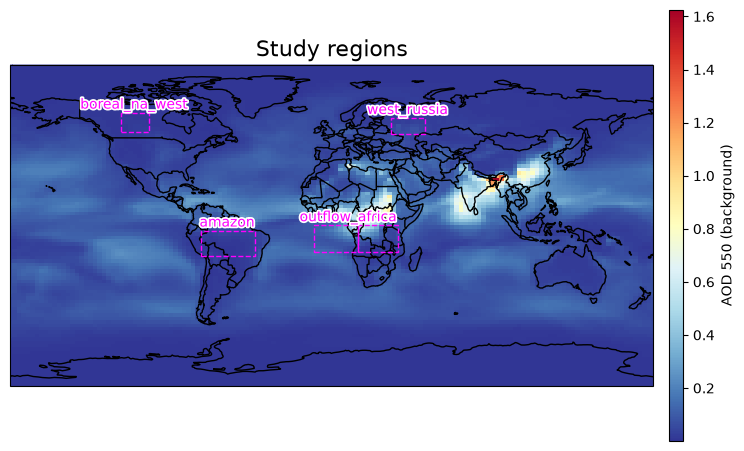

In [6]:
print('\n--- Regional map ---')
sample_field = data[sample_model]['od550aer']['od550aer'].isel(time=0)
region_boxes = {
    name: (cfg['lon_range'][0], cfg['lon_range'][1], cfg['lat_range'][0], cfg['lat_range'][1])
    for name, cfg in REGIONS.items() if name != 'global'
}
fig = ct.fake_uba_map(
    lon=sample_field.lon.values,
    lat=sample_field.lat.values,
    c_array=sample_field.values,
    labels='AOD 550 (background)',
    title='Study regions',
    region_boxes=region_boxes,
    show_region_labels=True,
    region_edgecolor='magenta',
    region_linewidth=1.0,
    mycolor='RdYlBu_r',
    cbar_orientation='vertical',
    cbar_extend='neither',
    show=False,
)
if SAVE_FIGURE:
    save_path = project_root / 'notebooks' / 'study_regions_map.png'
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f'Saved regional map: {save_path}')
    plt.close(fig)


## Load POLDER observations


In [7]:
polder_path = project_root / 'Data' / 'AP3_POLDER_Collocated' / 'POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet'
print(f'\nLoading POLDER observations: {polder_path}')
polder_cols = ['time', 'longitude', 'latitude', 'AOD_550', 'AAOD_550', 'AOD_440', 'AOD_870']
polder_df = pd.read_parquet(polder_path, columns=polder_cols)
polder_df['time'] = pd.to_datetime(polder_df['time'])
polder_df['month'] = polder_df['time'].dt.to_period('M')
with np.errstate(divide='ignore', invalid='ignore'):
    polder_df['SSA'] = 1.0 - polder_df['AAOD_550'] / polder_df['AOD_550']
    polder_df['AE'] = -np.log(polder_df['AOD_550'] / polder_df['AOD_870']) / np.log(550.0 / 870.0)
polder_df = polder_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['SSA', 'AE', 'AAOD_550', 'AOD_550'])
print(f'POLDER rows after filtering: {len(polder_df)}')


def polder_region_mask(df, lon_range, lat_range):
    lon_min, lon_max = lon_range
    lat_min, lat_max = lat_range
    if lon_min > lon_max:
        mask_lon = (df['longitude'] >= lon_min) | (df['longitude'] <= lon_max)
    else:
        mask_lon = (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
    mask_lat = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)
    return mask_lon & mask_lat


def polder_monthly_means(df, region_name):
    """Area-weighted monthly regional means from POLDER 3-hourly data."""
    cfg = REGIONS[region_name]
    mask = polder_region_mask(df, cfg['lon_range'], cfg['lat_range'])
    sub = df[mask].copy()
    t0, t1 = cfg['time_slice']
    sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
    if sub.empty:
        return pd.DataFrame()
    sub['coslat'] = np.cos(np.deg2rad(sub['latitude']))
    rows = []
    for month, g in sub.groupby('month'):
        if len(g) < 3:
            continue
        w = g['coslat']
        rows.append({
            'month': month,
            'time': pd.Timestamp(month.start_time),
            'SSA': np.average(g['SSA'], weights=w),
            'AE': np.average(g['AE'], weights=w),
            'AAOD_550': np.average(g['AAOD_550'], weights=w),
            'AOD_550': np.average(g['AOD_550'], weights=w),
            'n': len(g),
        })
    return pd.DataFrame(rows)


polder_monthly = {region: polder_monthly_means(polder_df, region) for region in REGIONS}
print('POLDER monthly means per region:')
for region, df in polder_monthly.items():
    print(f'  {region}: {len(df)} months')



Loading POLDER observations: /scistor/guest/gbb083/AeroCom/Data/AP3_POLDER_Collocated/POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet
POLDER rows after filtering: 1904702
POLDER monthly means per region:
  africa: 4 months
  amazon: 4 months
  outflow_af: 4 months
  west_russia: 3 months
  boreal_na_west: 3 months


## Load GPCP precipitation


In [8]:
gpcp_path = project_root / 'Data' / 'Prec' / 'GPCP_2010_0-360.nc'
print(f'\nLoading GPCP precipitation: {gpcp_path}')
gpcp = xr.open_dataset(gpcp_path)
gpcp_precip = gpcp['sat_gauge_precip']
print(f'GPCP dims: {gpcp_precip.dims}, shape: {gpcp_precip.shape}')


def gpcp_region_mean(precip_da, region_name):
    """Compute area-weighted regional mean of GPCP precipitation."""
    cfg = REGIONS[region_name]
    lon_min, lon_max = cfg['lon_range']
    lat_min, lat_max = cfg['lat_range']
    # Select lat/lon (handle wrap-around)
    if lon_min > lon_max:
        sub = xr.concat([
            precip_da.sel(lon=slice(lon_min, 360)),
            precip_da.sel(lon=slice(0, lon_max)),
        ], dim='lon')
    else:
        sub = precip_da.sel(lon=slice(lon_min, lon_max))
    sub = sub.sel(lat=slice(lat_max, lat_min))  # GPCP lat decreasing
    # Time slice
    sub = sub.sel(time=slice(*cfg['time_slice']))
    # 2D area weights proportional to cos(latitude) on a regular lat/lon grid
    coslat = np.cos(np.deg2rad(sub.lat))
    weights = coslat * xr.ones_like(sub.isel(time=0))
    weights = weights / weights.sum()
    # Weighted spatial mean at each time step
    spatial_mean = (sub * weights).sum(dim=['lat', 'lon'])
    return spatial_mean


gpcp_region = {region: gpcp_region_mean(gpcp_precip, region) for region in REGIONS}
print('GPCP regional mean precipitation (mm/day):')
for region, da in gpcp_region.items():
    mean_val = float(da.mean().values) if da.size else np.nan
    print(f'  {region}: {mean_val:.3f}')



Loading GPCP precipitation: /scistor/guest/gbb083/AeroCom/Data/Prec/GPCP_2010_0-360.nc
GPCP dims: ('time', 'lat', 'lon'), shape: (12, 360, 720)
GPCP regional mean precipitation (mm/day):
  africa: 1.105
  amazon: 1.896
  outflow_af: 0.294
  west_russia: 1.783
  boreal_na_west: 2.409


## POLDER-GRASP homogenization (Zhong et al. 2023)


In [9]:
def sample_model_aaod_at_polder(model_da, polder_sub):
    """Sample model monthly AAOD at POLDER locations/times; return weighted mean."""
    if model_da is None or polder_sub.empty:
        return np.nan
    lat_vals = model_da.lat.values
    lon_vals = model_da.lon.values
    lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
    times = pd.to_datetime(model_da.time.values)
    polder_times = pd.to_datetime(polder_sub['time'].values)
    month_idx = np.array([
        np.argmin(np.abs(times - pd.Timestamp(t).to_period('M').to_timestamp()))
        for t in polder_times
    ])
    vals = model_da.values[month_idx, lat_idx, lon_idx]
    weights = np.cos(np.deg2rad(polder_sub['latitude'].values))
    finite = np.isfinite(vals)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=weights[finite]))


def sample_model_ssa_at_polder(model_da, polder_sub):
    """Sample model monthly SSA at POLDER locations/times; return weighted mean.

    Same sampling scheme as ``sample_model_aaod_at_polder`` (item 2: SSA
    homogenization, mirroring the AAOD homogenization).
    """
    if model_da is None or polder_sub.empty:
        return np.nan
    lat_vals = model_da.lat.values
    lon_vals = model_da.lon.values
    lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
    times = pd.to_datetime(model_da.time.values)
    polder_times = pd.to_datetime(polder_sub['time'].values)
    month_idx = np.array([
        np.argmin(np.abs(times - pd.Timestamp(t).to_period('M').to_timestamp()))
        for t in polder_times
    ])
    vals = model_da.values[month_idx, lat_idx, lon_idx]
    weights = np.cos(np.deg2rad(polder_sub['latitude'].values))
    finite = np.isfinite(vals)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=weights[finite]))


def _homogenize_polder_variable(model_seasonal_dict, polder_raw, obs_col, model_var_key,
                                 sampler_fn, var_label):
    """Homogenize a regional POLDER-observed mean via model regional-vs-sampled regression.

    Generalizes the original AAOD-only homogenization (Zhong et al. 2023) so it
    can be reused for SSA (item 2). For each source region, fit::

        sampled = a * regional + b

    across models (``regional`` = model's regional/seasonal mean; ``sampled`` =
    model sampled at POLDER pixel locations/times), then invert with the raw
    POLDER-sampled mean to obtain the homogenized regional observation.

    Returns
    -------
    homogenized : dict[region] -> float
        Homogenized (or, for the outflow / skipped regions, raw sampled)
        regional observational estimate.
    details : dict[region] -> dict
        Regression detail needed for the Fig. S17-style diagnostic plot:
        ``x`` (regional model values), ``y`` (POLDER-sampled model values),
        ``models``, ``a``, ``b``, ``r2``, ``obs_sampled`` (raw POLDER mean),
        ``homogenized`` (predicted regional value), or ``{'skipped': True}``.
    """
    homogenized = {}
    details = {}
    print(f'\n--- POLDER-GRASP homogenization ({var_label}) ---')
    for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
        cfg = REGIONS[region]
        sub = polder_raw[polder_region_mask(polder_raw, cfg['lon_range'], cfg['lat_range'])].copy()
        t0, t1 = cfg['time_slice']
        sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
        if sub.empty:
            print(f'  {region}: no POLDER samples')
            details[region] = {'skipped': True}
            continue
        obs_sampled = float(np.average(sub[obs_col], weights=np.cos(np.deg2rad(sub['latitude']))))

        if region == OUTFLOW_REGION:
            # Homogenization is defined for source regions; keep sampled mean for outflow.
            homogenized[region] = obs_sampled
            details[region] = {'skipped': True, 'obs_sampled': obs_sampled}
            print(f'  {region}: using raw sampled {var_label}={obs_sampled:.5f} (no homogenization)')
            continue

        regional = model_seasonal_dict[region].get(model_var_key, {})
        sampled = {}
        for model in regional:
            da = data_derived[model].get(model_var_key)
            s = sampler_fn(da, sub)
            if np.isfinite(s) and np.isfinite(float(regional[model])):
                sampled[model] = s
        common = [m for m in regional if m in sampled]
        if len(common) < 3:
            print(f'  {region}: homogenization skipped (only {len(common)} models); '
                  f'falling back to raw sampled {var_label}={obs_sampled:.5f}')
            homogenized[region] = obs_sampled
            details[region] = {'skipped': True, 'obs_sampled': obs_sampled}
            continue

        x = np.array([float(regional[m]) for m in common])  # regional (model seasonal mean)
        y = np.array([sampled[m] for m in common])          # POLDER-sampled model value
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        a, b = float(coeffs[0]), float(coeffs[1])
        y_pred = a * x + b
        r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
        # Invert: regional_obs = (sampled_obs - b) / a
        homogenized_regional = (obs_sampled - b) / a if a != 0 else np.nan
        homogenized[region] = homogenized_regional
        details[region] = {
            'skipped': False, 'models': common, 'x': x, 'y': y,
            'a': a, 'b': b, 'r2': r2, 'obs_sampled': obs_sampled,
            'homogenized': homogenized_regional,
        }
        print(f'  {region}: sampled = {a:.4f}*regional + {b:.4f}  (R^2={r2:.3f}, n={len(common)})')
        print(f'    raw sampled {var_label}={obs_sampled:.5f} -> '
              f'homogenized regional {var_label}={homogenized_regional:.5f}')
    return homogenized, details


if POLDER_HOMOGENIZE:
    aaod_obs_by_region, aaod_homog_details = _homogenize_polder_variable(
        model_seasonal, polder_df, 'AAOD_550', 'abs550aer', sample_model_aaod_at_polder, 'AAOD')
else:
    print('\n--- POLDER AAOD homogenization DISABLED; using area-weighted regional monthly means ---')
    aaod_obs_by_region = {
        region: float(polder_monthly[region]['AAOD_550'].mean())
        if not polder_monthly[region].empty else np.nan
        for region in SOURCE_REGIONS + [OUTFLOW_REGION]
    }
    aaod_homog_details = {}
    for region, val in aaod_obs_by_region.items():
        print(f'  {region}: AAOD_obs={val:.5f}')

if SSA_POLDER_HOMOGENIZE:
    ssa_obs_by_region, ssa_homog_details = _homogenize_polder_variable(
        model_seasonal, polder_df, 'SSA', 'SSA', sample_model_ssa_at_polder, 'SSA')
else:
    print('\n--- POLDER SSA homogenization DISABLED; using area-weighted regional monthly means ---')
    ssa_obs_by_region = {
        region: float(polder_monthly[region]['SSA'].mean())
        if not polder_monthly[region].empty else np.nan
        for region in SOURCE_REGIONS + [OUTFLOW_REGION]
    }
    ssa_homog_details = {}
    for region, val in ssa_obs_by_region.items():
        print(f'  {region}: SSA_obs={val:.5f}')



--- POLDER-GRASP homogenization (AAOD) ---
  africa: sampled = 1.1818*regional + -0.0036  (R^2=0.987, n=15)
    raw sampled AAOD=0.08185 -> homogenized regional AAOD=0.07229
  amazon: sampled = 2.2064*regional + -0.0144  (R^2=0.962, n=15)
    raw sampled AAOD=0.04921 -> homogenized regional AAOD=0.02885
  west_russia: sampled = 1.2877*regional + -0.0006  (R^2=0.988, n=15)
    raw sampled AAOD=0.02811 -> homogenized regional AAOD=0.02228
  boreal_na_west: sampled = 1.2130*regional + -0.0001  (R^2=0.986, n=15)
    raw sampled AAOD=0.04473 -> homogenized regional AAOD=0.03698
  outflow_af: using raw sampled AAOD=0.07639 (no homogenization)

--- POLDER-GRASP homogenization (SSA) ---
  africa: sampled = 1.0619*regional + -0.0640  (R^2=0.992, n=15)
    raw sampled SSA=0.85457 -> homogenized regional SSA=0.86508
  amazon: sampled = 1.2840*regional + -0.2806  (R^2=0.966, n=15)
    raw sampled SSA=0.90304 -> homogenized regional SSA=0.92184
  west_russia: sampled = 1.1752*regional + -0.1799  (

## Figure S17 style: POLDER-GRASP homogenization diagnostic (AAOD and SSA)

For each source region and variable (AAOD, SSA): one point per model showing
regional (seasonal-mean) model value (x) vs. the same model sampled at POLDER
pixel locations/times (y), the OLS fit with R^2, a horizontal dashed line at
the raw POLDER-sampled mean (y-axis quantity), and a vertical dashed line at
the resulting homogenized regional value (x-axis quantity, from inverting the
regression) -- i.e. the value that, if it were the true regional model mean,
would reproduce the observed POLDER-sampled mean.


--- Figure S17 style: POLDER-GRASP homogenization regression ---


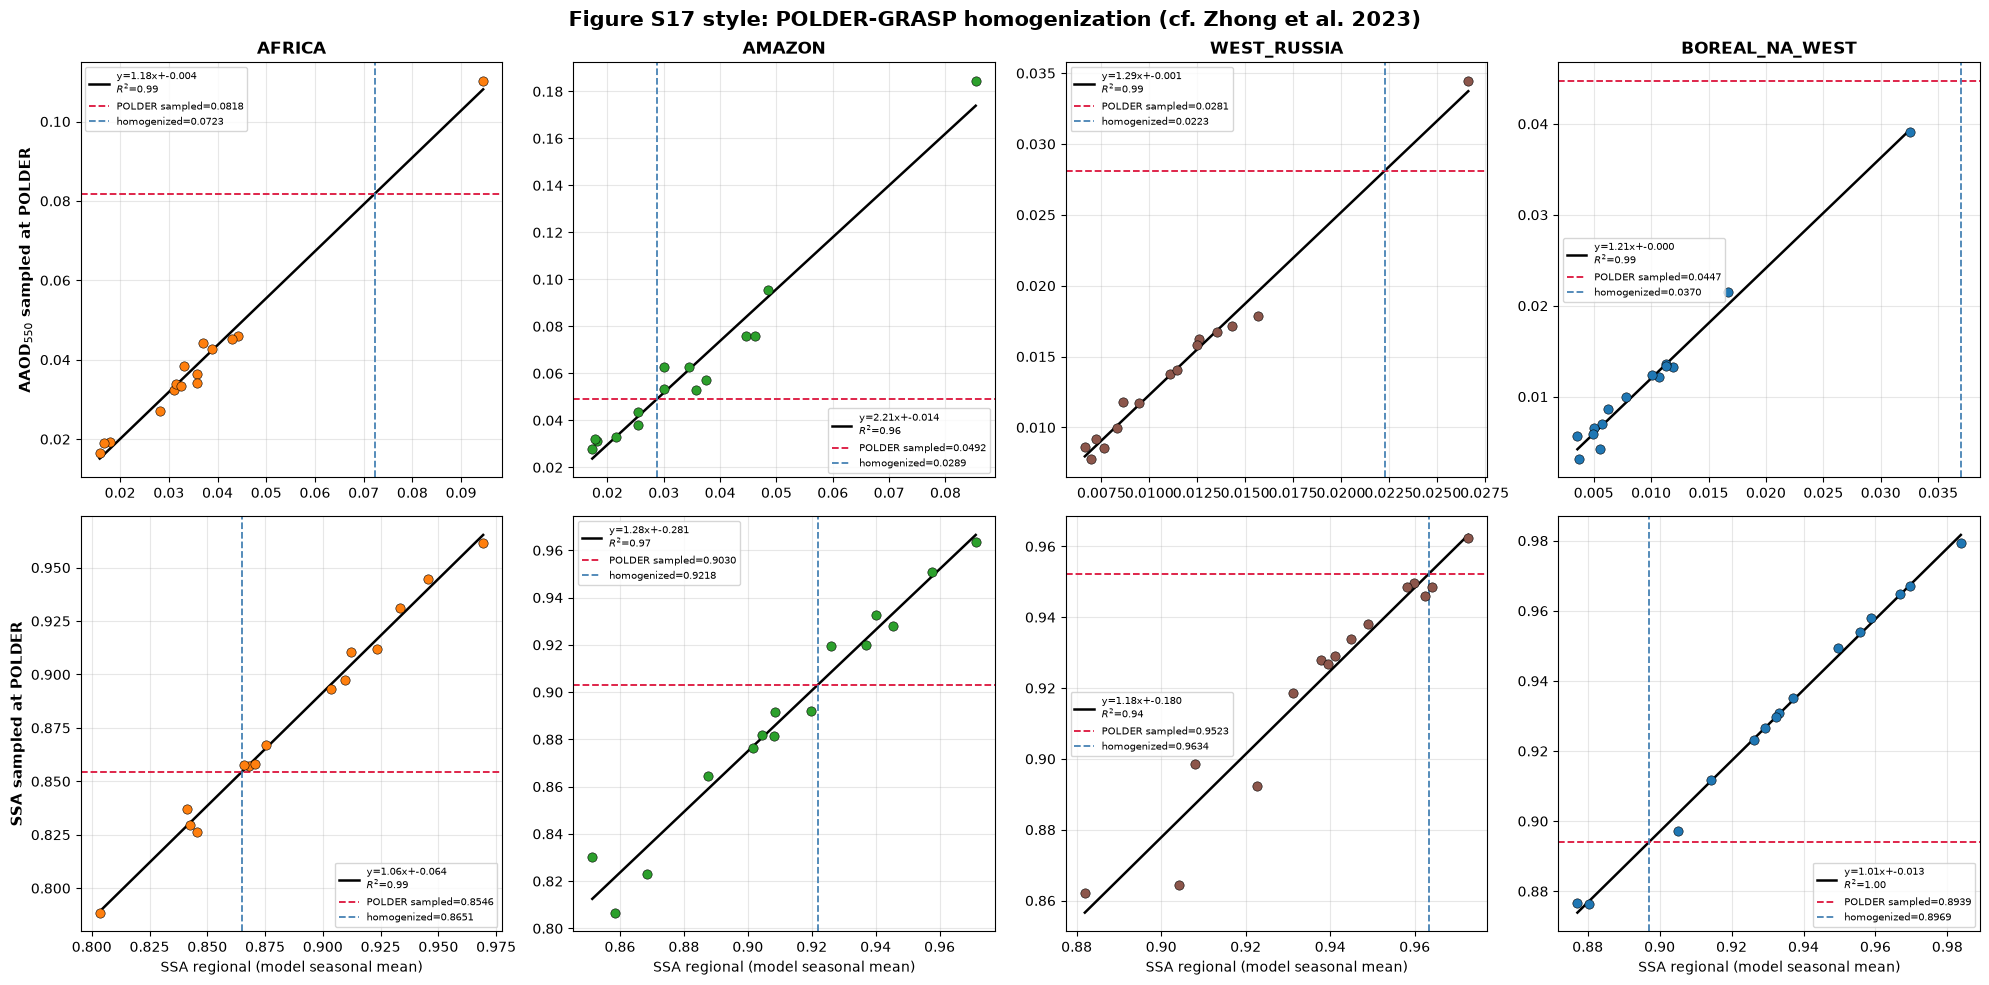

In [10]:
print('\n--- Figure S17 style: POLDER-GRASP homogenization regression ---')
_s17_panels = [
    ('AAOD', aaod_homog_details, 'AAOD$_{550}$ sampled at POLDER'),
    ('SSA', ssa_homog_details, 'SSA sampled at POLDER'),
]
_s17_any = any(not d.get('skipped', True) for _, det, _ in _s17_panels for d in det.values())
if _s17_any:
    fig, axes = plt.subplots(2, len(SOURCE_REGIONS), figsize=(5 * len(SOURCE_REGIONS), 10), squeeze=False)
    for row, (var_name, details, ylabel) in enumerate(_s17_panels):
        for col, region in enumerate(SOURCE_REGIONS):
            ax = axes[row, col]
            d = details.get(region, {})
            if d.get('skipped', True):
                ax.text(0.5, 0.5, 'no homogenization\n(insufficient data)',
                        ha='center', va='center', transform=ax.transAxes, fontsize=10, color='gray')
                ax.set_xticks([]); ax.set_yticks([])
                if col == 0:
                    ax.set_ylabel(ylabel, fontweight='bold')
                if row == 0:
                    ax.set_title(region.upper(), fontweight='bold')
                continue
            x, y = d['x'], d['y']
            a, b, r2 = d['a'], d['b'], d['r2']
            color = REGION_COLORS.get(region, 'tab:blue')
            ax.scatter(x, y, s=45, color=color, edgecolors='black', linewidths=0.4, zorder=4)
            x_line = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_line, a * x_line + b, '-', color='black', linewidth=1.8,
                    label=f'y={a:.2f}x+{b:.3f}\n$R^2$={r2:.2f}')
            ax.axhline(d['obs_sampled'], color='crimson', linestyle='--', linewidth=1.3,
                       label=f'POLDER sampled={d["obs_sampled"]:.4f}')
            ax.axvline(d['homogenized'], color='steelblue', linestyle='--', linewidth=1.3,
                       label=f'homogenized={d["homogenized"]:.4f}')
            ax.legend(fontsize=7, loc='best')
            ax.grid(alpha=0.3)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
            if row == len(_s17_panels) - 1:
                ax.set_xlabel(f'{var_name} regional (model seasonal mean)', fontsize=10)
            if row == 0:
                ax.set_title(region.upper(), fontweight='bold')
    plt.suptitle('Figure S17 style: POLDER-GRASP homogenization (cf. Zhong et al. 2023)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    fig_path = project_root / 'notebooks' / 'figure_s17_homogenization.png'
    if SAVE_FIGURE:
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {fig_path}')
        plt.close(fig)
else:
    print('  Skipped: no region had a valid AAOD or SSA homogenization regression '
          '(POLDER_HOMOGENIZE / SSA_POLDER_HOMOGENIZE disabled or insufficient data).')


## Model regressions (source regions)
Constrained estimates from seasonal-mean observations

In [12]:
print('\n--- Model regressions ---')
print(f'  MAC–SSA: INTERCEPT_0={INTERCEPT_0} '
      f"({'through origin' if INTERCEPT_0 else 'with intercept'})")

regression_rows = []
regression_excluded = []
for region in SOURCE_REGIONS:  # main regressions on source regions only
    for model in models:
        ssa = model_seasonal[region]['SSA'].get(model)
        mac = model_seasonal[region]['MAC'].get(model)
        ae = model_seasonal[region]['AE'].get(model)
        lt = model_seasonal[region]['lifetime_BC_OA'].get(model)
        precip = model_seasonal[region]['precip'].get(model)
        if not all(v is not None for v in [ssa, mac, ae, lt, precip]):
            continue
        if not np.isfinite(float(lt)):
            regression_excluded.append({'region': region, 'model': model, 'reason': 'non-finite lifetime'})
            continue
        regression_rows.append({
            'region': region, 'model': model,
            'SSA': float(ssa), 'MAC': float(mac), 'AE': float(ae),
            'lifetime': float(lt), 'inv_lifetime': 1.0 / float(lt),
            'precip': float(precip),
        })
if regression_excluded:
    print(f'  Excluded {len(regression_excluded)} model/region points due to lifetime:')
    for item in regression_excluded:
        print(f'    {item["model"]} {item["region"]}')
reg_df = pd.DataFrame(regression_rows)
print(f'Regression data rows (seasonal means, source regions): {len(reg_df)}')

mac_ssa_results = {}
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', 'SSA'])
    if len(sub) < 3:
        print(f'{region}: skipped MAC vs SSA (only {len(sub)} points)')
        continue
    x = sub['SSA'].values
    y = sub['MAC'].values
    if INTERCEPT_0:
        F = np.nansum(x * y) / np.nansum(x ** 2)
        b = 0.0
        residuals = y - F * x
        r2 = 1 - np.nansum(residuals ** 2) / np.nansum(y ** 2)
        print(f'{region}: MAC = {F:.4f} * SSA  (through origin; uncentered R^2={r2:.3f}, n={len(sub)})')
    else:
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        F, b = float(coeffs[0]), float(coeffs[1])
        y_pred = F * x + b
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f'{region}: MAC = {F:.4f} * SSA + {b:.4f}  (R^2={r2:.3f}, n={len(sub)})')
    mac_ssa_results[region] = {'F': F, 'b': b, 'r2': r2, 'n': len(sub)}

inv_lt_results = {}
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip', 'AE'])
    if len(sub) < 4:
        print(f'{region}: skipped 1/tau regression (only {len(sub)} points)')
        continue
    X = np.column_stack([sub['precip'].values, sub['AE'].values])
    y = sub['inv_lifetime'].values
    X_ols = np.column_stack([np.ones(len(X)), X])
    coeffs, _, _, _ = np.linalg.lstsq(X_ols, y, rcond=None)
    y_pred = X_ols @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    inv_lt_results[region] = {
        'intercept': float(coeffs[0]), 'alpha': float(coeffs[1]), 'beta': float(coeffs[2]),
        'r2': r2, 'n': len(sub),
    }
    print(f'{region}: 1/tau = {coeffs[0]:.4f} + {coeffs[1]:.4f}*Pr + {coeffs[2]:.4f}*AE '
          f'(R^2={r2:.3f}, n={len(sub)})')



--- Model regressions ---
  MAC–SSA: INTERCEPT_0=False (with intercept)
  Excluded 15 model/region points due to lifetime:
    CAM5_CTRL2016 africa
    EC-Earth3-AerChem-met2010_AP3-CTRL2019 africa
    GFDL-AM4-met2010_AP3-CTRL africa
    TM5-met2010_AP3-CTRL2019 africa
    CAM5_CTRL2016 amazon
    EC-Earth3-AerChem-met2010_AP3-CTRL2019 amazon
    GFDL-AM4-met2010_AP3-CTRL amazon
    TM5-met2010_AP3-CTRL2019 amazon
    EC-Earth3-AerChem-met2010_AP3-CTRL2019 west_russia
    GFDL-AM4-met2010_AP3-CTRL west_russia
    TM5-met2010_AP3-CTRL2019 west_russia
    CAM5_CTRL2016 boreal_na_west
    EC-Earth3-AerChem-met2010_AP3-CTRL2019 boreal_na_west
    GFDL-AM4-met2010_AP3-CTRL boreal_na_west
    TM5-met2010_AP3-CTRL2019 boreal_na_west
Regression data rows (seasonal means, source regions): 45
africa: MAC = -11.6932 * SSA + 11.4812  (R^2=0.560, n=11)
amazon: MAC = -9.3439 * SSA + 9.3381  (R^2=0.448, n=11)
west_russia: MAC = -25.5899 * SSA + 25.4773  (R^2=0.469, n=12)
boreal_na_west: MAC = -9.01

## Constrained estimates from observations


In [13]:
print('\n--- Constrained estimates from observations ---')
constrained = []
for region in SOURCE_REGIONS:
    polder_df_region = polder_monthly[region]
    if polder_df_region.empty:
        print(f'  {region}: skipped (no POLDER data)')
        continue
    if region not in mac_ssa_results or region not in inv_lt_results:
        print(f'  {region}: skipped (no model regression)')
        continue
    gpcp_ts = gpcp_region[region]
    mac_params = mac_ssa_results[region]
    lt_params = inv_lt_results[region]

    ssa_obs_mean = float(ssa_obs_by_region.get(region, polder_df_region['SSA'].mean()))
    ae_obs_mean = float(polder_df_region['AE'].mean())
    aaod_obs_mean = float(aaod_obs_by_region.get(region, polder_df_region['AAOD_550'].mean()))
    precip_obs_mean = float(gpcp_ts.mean().values) if gpcp_ts.size else np.nan

    mac_c = mac_params['F'] * ssa_obs_mean + mac_params.get('b', 0.0)
    inv_lt_c = (lt_params['intercept']
                + lt_params['alpha'] * precip_obs_mean
                + lt_params['beta'] * ae_obs_mean)
    tau_c = 1.0 / inv_lt_c if inv_lt_c > 0 else np.nan
    # E from AAOD/(tau*MAC) is in g m^-2 day^-1; convert to kg m^-2 s^-1 for comparison with model emissions
    e_c_g_m2_day = aaod_obs_mean / (tau_c * mac_c) if (tau_c > 0 and mac_c > 0) else np.nan
    e_c = e_c_g_m2_day / (1000.0 * 86400.0)

    constrained.append({
        'region': region,
        'SSA_obs': ssa_obs_mean, 'AE_obs': ae_obs_mean, 'AAOD_obs': aaod_obs_mean,
        'precip_obs': precip_obs_mean,
        'MAC_c': mac_c, 'tau_c': tau_c,
        'E_c_g_m2_day': e_c_g_m2_day, 'E_c': e_c,
        'AAOD_homogenized': bool(POLDER_HOMOGENIZE),
        'MAC_intercept_used': not INTERCEPT_0,
        'SSA_homogenized': bool(SSA_POLDER_HOMOGENIZE),
    })
    print(f'  {region}: MAC_c={mac_c:.4f}, tau_c={tau_c:.2f} d, '
          f'E_c={e_c:.3e}, AAOD_obs={aaod_obs_mean:.5f} '
          f'(homogenized={POLDER_HOMOGENIZE})')

constrained_df = pd.DataFrame(constrained)
print(f'Constrained rows: {len(constrained_df)}')



--- Constrained estimates from observations ---
  africa: MAC_c=1.3656, tau_c=3.16 d, E_c=1.941e-10, AAOD_obs=0.07229 (homogenized=True)
  amazon: MAC_c=0.7245, tau_c=1.69 d, E_c=2.725e-10, AAOD_obs=0.02885 (homogenized=True)
  west_russia: MAC_c=0.8245, tau_c=3.00 d, E_c=1.042e-10, AAOD_obs=0.02228 (homogenized=True)
  boreal_na_west: MAC_c=0.9373, tau_c=1.46 d, E_c=3.121e-10, AAOD_obs=0.03698 (homogenized=True)
Constrained rows: 4


## Figure S3 replication: 1/lifetime vs precipitation (source regions)

Replicates Zhong et al. (2023) Fig. S3: for each source region, seasonal-mean 1/lifetime (post-aggregation-filtered, see `POST_AGG_LIFETIME_MAX_DAYS`/`MIN_DAYS`) is regressed against seasonal-mean precipitation only (single predictor, for visual consistency with the paper). The actual constrained lifetime used elsewhere in this notebook also includes AE (see `inv_lt_results` above).



--- Figure S3 replication: 1/lifetime vs precipitation ---


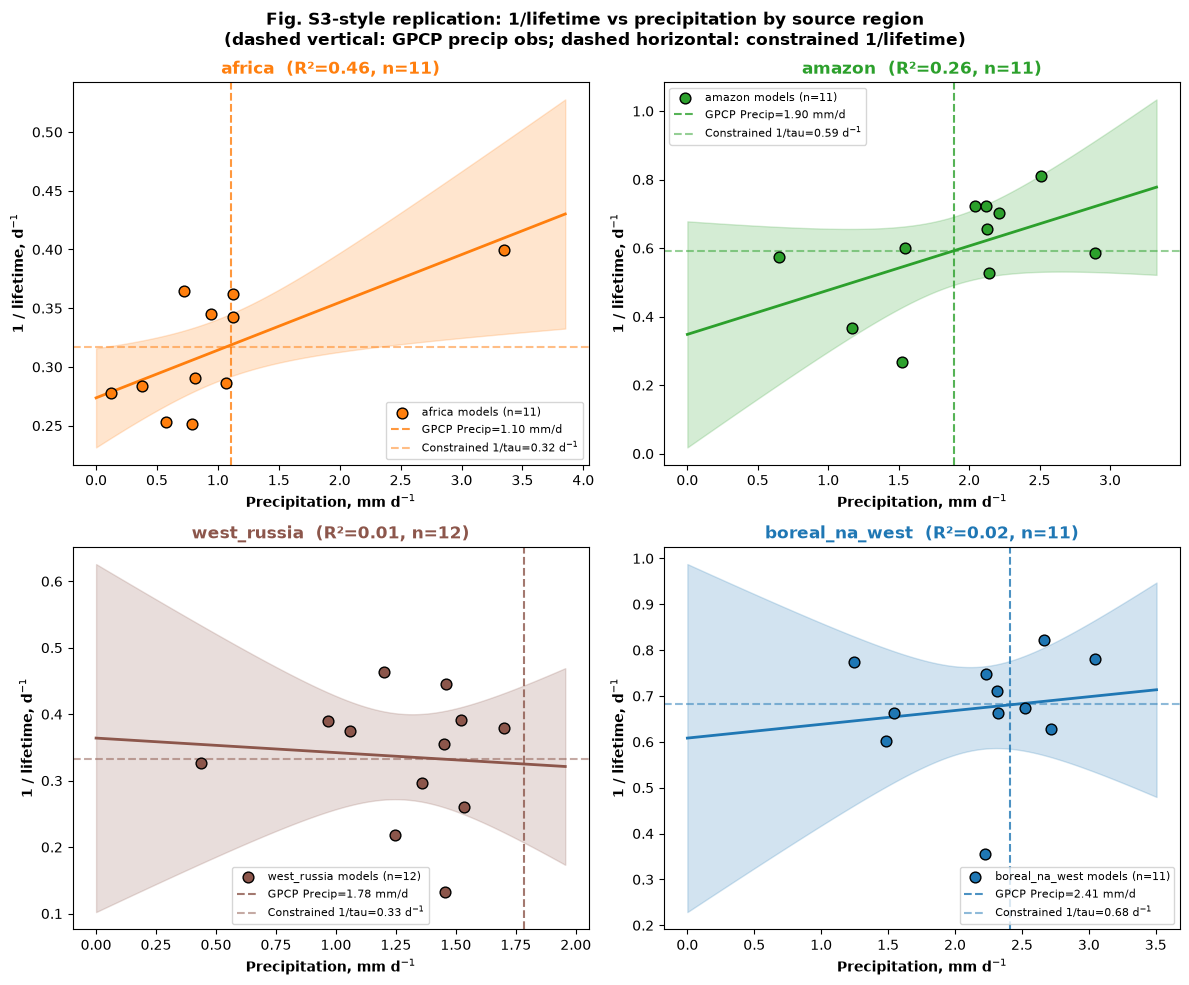

In [14]:
print('\n--- Figure S3 replication: 1/lifetime vs precipitation ---')

fig_s3_regions = SOURCE_REGIONS  # africa, amazon, west_russia, boreal_na_west
region_colors_s3 = {
    'africa': '#ff7f0e', 'amazon': '#2ca02c',
    'west_russia': '#8c564b', 'boreal_na_west': '#1f77b4',
}

ncols = 2
nrows = int(np.ceil(len(fig_s3_regions) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), squeeze=False)

for idx, region in enumerate(fig_s3_regions):
    ax = axes[idx // ncols][idx % ncols]
    color = region_colors_s3.get(region, '#333333')

    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip'])
    if len(sub) < 3:
        ax.set_title(f'{region}: insufficient data (n={len(sub)})')
        ax.axis('off')
        continue

    x = sub['precip'].values
    y = sub['inv_lifetime'].values

    # Simple OLS: 1/tau = m * Precip + b (precip-only, matches paper's Fig. S3 visualization;
    # the actual constrained regression used elsewhere also includes AE).
    X = np.column_stack([x, np.ones(len(x))])
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    m, b = float(coeffs[0]), float(coeffs[1])
    y_pred = m * x + b
    resid = y - y_pred
    dof = max(len(x) - 2, 1)
    mse = np.sum(resid ** 2) / dof
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - np.sum(resid ** 2) / ss_tot if ss_tot > 0 else np.nan

    x_line = np.linspace(0, max(x.max() * 1.15, 0.1), 100)
    y_line = m * x_line + b
    x_mean = x.mean()
    Sxx = np.sum((x - x_mean) ** 2)
    se_line = np.sqrt(mse * (1.0 / len(x) + (x_line - x_mean) ** 2 / max(Sxx, 1e-12)))
    tval = stats.t.ppf(0.975, dof)
    ci = tval * se_line

    ax.scatter(x, y, color=color, edgecolor='k', s=60, zorder=3, label=f'{region} models (n={len(sub)})')
    ax.plot(x_line, y_line, color=color, lw=2)
    ax.fill_between(x_line, y_line - ci, y_line + ci, color=color, alpha=0.2)

    # GPCP observed precipitation (vertical) and constrained 1/lifetime (horizontal)
    gpcp_ts = gpcp_region.get(region)
    gpcp_val = float(gpcp_ts.mean().values) if gpcp_ts is not None and gpcp_ts.size else np.nan
    csub = constrained_df[constrained_df['region'] == region]
    tau_c_mean = float(csub['tau_c'].mean()) if not csub.empty else np.nan
    inv_tau_c = 1.0 / tau_c_mean if tau_c_mean and tau_c_mean > 0 else np.nan

    if np.isfinite(gpcp_val):
        ax.axvline(gpcp_val, color=color, linestyle='--', alpha=0.8,
                    label=f'GPCP Precip={gpcp_val:.2f} mm/d')
    if np.isfinite(inv_tau_c):
        ax.axhline(inv_tau_c, color=color, linestyle='--', alpha=0.5,
                    label=f'Constrained 1/tau={inv_tau_c:.2f} d$^{{-1}}$')

    ax.set_xlabel('Precipitation, mm d$^{-1}$', fontweight='bold')
    ax.set_ylabel('1 / lifetime, d$^{-1}$', fontweight='bold')
    ax.set_title(f'{region}  (R\u00b2={r2:.2f}, n={len(sub)})', fontweight='bold', color=color)
    ax.legend(fontsize=8, loc='best')

for j in range(len(fig_s3_regions), nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

fig.suptitle('Fig. S3-style replication: 1/lifetime vs precipitation by source region\n'
             '(dashed vertical: GPCP precip obs; dashed horizontal: constrained 1/lifetime)',
             fontweight='bold')
plt.tight_layout()
if SAVE_FIGURE:
    fig_path = project_root / 'notebooks' / 'figureS3_lifetime_precip.png'
    fig.savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f'Saved: {fig_path}')
plt.show()


## Source-region error decomposition (Fig. 3 style)


In [16]:
print('\n--- Error decomposition (source regions only) ---')
print(f'  Regions: {SOURCE_REGIONS}')
print(f'  Outflow ({OUTFLOW_REGION}) is handled separately via the meta-model.')

decomp_rows = []
for region in SOURCE_REGIONS:
    csub = constrained_df[constrained_df['region'] == region]
    if csub.empty:
        print(f'  {region}: skipped (no constrained estimate)')
        continue
    mac_c = float(csub['MAC_c'].mean())
    tau_c = float(csub['tau_c'].mean())
    aaod_c = float(csub['AAOD_obs'].mean())
    e_c = float(csub['E_c'].mean())

    for model in sorted(models):
        mac_model = model_seasonal[region]['MAC'].get(model)
        lt_model = model_seasonal[region]['lifetime_BC_OA'].get(model)
        emi_model = model_seasonal[region].get('emi_BC_OA', {}).get(model)
        aaod_model = None
        if (model_seasonal[region].get('load_BC_OA', {}).get(model) is not None
                and model_seasonal[region].get('MAC', {}).get(model) is not None):
            aaod_model = (float(model_seasonal[region]['MAC'][model])
                          * float(model_seasonal[region]['load_BC_OA'][model]) * 1000.0)

        if any(v is None or (isinstance(v, float) and np.isnan(v))
               for v in [mac_model, lt_model, emi_model, mac_c, tau_c, aaod_c, e_c]):
            continue

        mac_model = float(mac_model)
        lt_model = float(lt_model)
        emi_model = float(emi_model)
        emi_model_g = emi_model * 1000.0 * 86400.0
        e_c_g = e_c * 1000.0 * 86400.0
        aaod_model = float(aaod_model) if aaod_model is not None else emi_model_g * lt_model * mac_model

        dMAC = mac_model - mac_c
        dtau = lt_model - tau_c
        dE_g = emi_model_g - e_c_g
        dAAOD_E = dE_g * tau_c * mac_c
        dAAOD_tau = e_c_g * dtau * mac_c
        dAAOD_MAC = e_c_g * tau_c * dMAC
        dAAOD_total = aaod_model - aaod_c
        cross = dAAOD_total - (dAAOD_E + dAAOD_tau + dAAOD_MAC)

        denom = abs(dAAOD_E) + abs(dAAOD_tau) + abs(dAAOD_MAC) + abs(cross)
        if denom > 0:
            pct_E = abs(dAAOD_E) / denom * 100
            pct_tau = abs(dAAOD_tau) / denom * 100
            pct_MAC = abs(dAAOD_MAC) / denom * 100
            pct_cross = abs(cross) / denom * 100
        else:
            pct_E = pct_tau = pct_MAC = pct_cross = np.nan

        decomp_rows.append({
            'region': region, 'model': model,
            'MAC_model': mac_model, 'MAC_c': mac_c,
            'tau_model': lt_model, 'tau_c': tau_c,
            'E_model': emi_model, 'E_c': e_c,
            'AAOD_model': aaod_model, 'AAOD_c': aaod_c,
            'dAAOD_E': dAAOD_E, 'dAAOD_tau': dAAOD_tau,
            'dAAOD_MAC': dAAOD_MAC, 'dAAOD_cross': cross,
            'dAAOD_total': dAAOD_total,
            'pct_E': pct_E, 'pct_tau': pct_tau,
            'pct_MAC': pct_MAC, 'pct_cross': pct_cross,
        })

decomp_df = pd.DataFrame(decomp_rows)
print(f'Decomposition rows: {len(decomp_df)}')
mean_decomp = decomp_df.groupby('region')[['pct_E', 'pct_tau', 'pct_MAC', 'pct_cross']].mean()
print(mean_decomp)

print('\nError decomposition vs Zhong et al. (2023) paper targets:')
for region in mean_decomp.index:
    if region not in PAPER_DECOMP:
        continue
    print(f'\n{region}:')
    for var, pap in PAPER_DECOMP[region].items():
        cur = mean_decomp.loc[region, var]
        print(f'  {var}: current={cur:.1f}%, paper≈{pap:.1f}%, diff={cur - pap:+.1f}%')



--- Error decomposition (source regions only) ---
  Regions: ['africa', 'amazon', 'west_russia', 'boreal_na_west']
  Outflow (outflow_af) is handled separately via the meta-model.
Decomposition rows: 45
                    pct_E    pct_tau    pct_MAC  pct_cross
region                                                    
africa          31.952339  14.146170  41.039724  12.861766
amazon          30.822324  18.156063  38.886604  12.135009
boreal_na_west  36.111357   8.426958  35.799731  19.661954
west_russia     31.984000  14.596750  31.474255  21.944995

Error decomposition vs Zhong et al. (2023) paper targets:

africa:
  pct_E: current=32.0%, paper≈40.0%, diff=-8.0%
  pct_tau: current=14.1%, paper≈15.0%, diff=-0.9%
  pct_MAC: current=41.0%, paper≈31.0%, diff=+10.0%

amazon:
  pct_E: current=30.8%, paper≈19.0%, diff=+11.8%
  pct_tau: current=18.2%, paper≈20.0%, diff=-1.8%
  pct_MAC: current=38.9%, paper≈47.0%, diff=-8.1%


## Outflow meta-model prediction (Supplementary Text 2)


In [17]:
print('\n--- Outflow meta-model (prediction target) ---')
print('  AAOD_out = a*(E*tau*MAC) + b*(E*tau) + c*MAC + d   [src = africa]')
print('  Outflow lifetime from load/emission is NOT used for the main decomposition.')

meta_rows = []
for model in models:
    aaod_out = model_seasonal[OUTFLOW_REGION].get('abs550aer', {}).get(model)
    e_src = model_seasonal[OUTFLOW_SOURCE].get('emi_BC_OA', {}).get(model)
    tau_src = model_seasonal[OUTFLOW_SOURCE].get('lifetime_BC_OA', {}).get(model)
    mac_src = model_seasonal[OUTFLOW_SOURCE].get('MAC', {}).get(model)
    if not all(v is not None and np.isfinite(float(v)) for v in [aaod_out, e_src, tau_src, mac_src]):
        continue
    e_src, tau_src, mac_src = float(e_src), float(tau_src), float(mac_src)
    meta_rows.append({
        'model': model,
        'AAOD_out': float(aaod_out),
        'E': e_src, 'tau': tau_src, 'MAC': mac_src,
        'X1': e_src * tau_src * mac_src,
        'X2': e_src * tau_src,
        'X3': mac_src,
    })
meta_df = pd.DataFrame(meta_rows)

outflow_meta_params = None
outflow_pred_df = pd.DataFrame()
if len(meta_df) < 4:
    print(f'  Insufficient models for outflow meta-model (n={len(meta_df)})')
else:
    X = meta_df[['X1', 'X2', 'X3']].values
    y = meta_df['AAOD_out'].values
    X_ols = np.column_stack([X, np.ones(len(X))])
    coeffs, _, _, _ = np.linalg.lstsq(X_ols, y, rcond=None)
    a, b, c, d = [float(v) for v in coeffs]
    y_pred = X_ols @ coeffs
    r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
    rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))
    nmb = float(np.sum(y_pred - y) / np.sum(y) * 100) if np.sum(y) != 0 else np.nan
    slope, intercept, _, _, _ = stats.linregress(y, y_pred)
    outflow_meta_params = {
        'a': a, 'b': b, 'c': c, 'd': d,
        'r2': r2, 'rmse': rmse, 'nmb': nmb, 'slope': slope, 'n': len(meta_df),
    }
    print(f'  Fit: AAOD = {a:.4e}*X1 + {b:.4e}*X2 + {c:.4e}*X3 + {d:.4e}')
    print(f'  Diagnostics: R^2={r2:.3f}, RMSE={rmse:.5f}, NMB={nmb:.1f}%, '
          f'slope(pred vs model)={slope:.3f}, n={len(meta_df)}')

    # Constrained outflow prediction from constrained African source values
    csrc = constrained_df[constrained_df['region'] == OUTFLOW_SOURCE]
    if not csrc.empty:
        e_c = float(csrc['E_c'].mean())
        tau_c = float(csrc['tau_c'].mean())
        mac_c = float(csrc['MAC_c'].mean())
        aaod_out_c = a * (e_c * tau_c * mac_c) + b * (e_c * tau_c) + c * mac_c + d
        print(f'  Constrained prediction AAOD_outflow_C = {aaod_out_c:.5f}')
        print(f'    using africa E_C={e_c:.3e}, tau_C={tau_c:.2f}, MAC_C={mac_c:.4f}')

        polder_out = polder_monthly[OUTFLOW_REGION]
        aaod_out_obs = float(aaod_obs_by_region.get(
            OUTFLOW_REGION,
            polder_out['AAOD_550'].mean() if not polder_out.empty else np.nan,
        ))
        print(f'  POLDER outflow AAOD_obs = {aaod_out_obs:.5f}')

        pred_rows = []
        for _, row in meta_df.iterrows():
            pred_model = a * row['X1'] + b * row['X2'] + c * row['X3'] + d
            pred_rows.append({
                'model': row['model'],
                'AAOD_model': row['AAOD_out'],
                'AAOD_meta_fit': pred_model,
                'AAOD_constrained': aaod_out_c,
                'AAOD_obs': aaod_out_obs,
            })
        outflow_pred_df = pd.DataFrame(pred_rows)
        print('\n  Outflow prediction summary (model / meta-fit / constrained / POLDER):')
        print(outflow_pred_df.describe()[['AAOD_model', 'AAOD_meta_fit', 'AAOD_constrained', 'AAOD_obs']])



--- Outflow meta-model (prediction target) ---
  AAOD_out = a*(E*tau*MAC) + b*(E*tau) + c*MAC + d   [src = africa]
  Outflow lifetime from load/emission is NOT used for the main decomposition.
  Fit: AAOD = 1.0897e+08*X1 + -1.7262e+07*X2 + -1.1521e-02*X3 + 1.6566e-03
  Diagnostics: R^2=0.973, RMSE=0.00274, NMB=-0.0%, slope(pred vs model)=0.973, n=11
  Constrained prediction AAOD_outflow_C = 0.06652
    using africa E_C=1.941e-10, tau_C=3.16, MAC_C=1.3656
  POLDER outflow AAOD_obs = 0.07639

  Outflow prediction summary (model / meta-fit / constrained / POLDER):
       AAOD_model  AAOD_meta_fit  AAOD_constrained   AAOD_obs
count   11.000000      11.000000          11.00000  11.000000
mean     0.026666       0.026666           0.06652   0.076386
std      0.017407       0.017168           0.00000   0.000000
min      0.008522       0.009740           0.06652   0.076386
25%      0.016882       0.017450           0.06652   0.076386
50%      0.022951       0.024038           0.06652   0.0763

## Figure 3 style plots (source regions)
add another option to change the SSA and MAC prediction to MAC = A* (1-SSA)





--- Figure 3 plots (source regions) ---


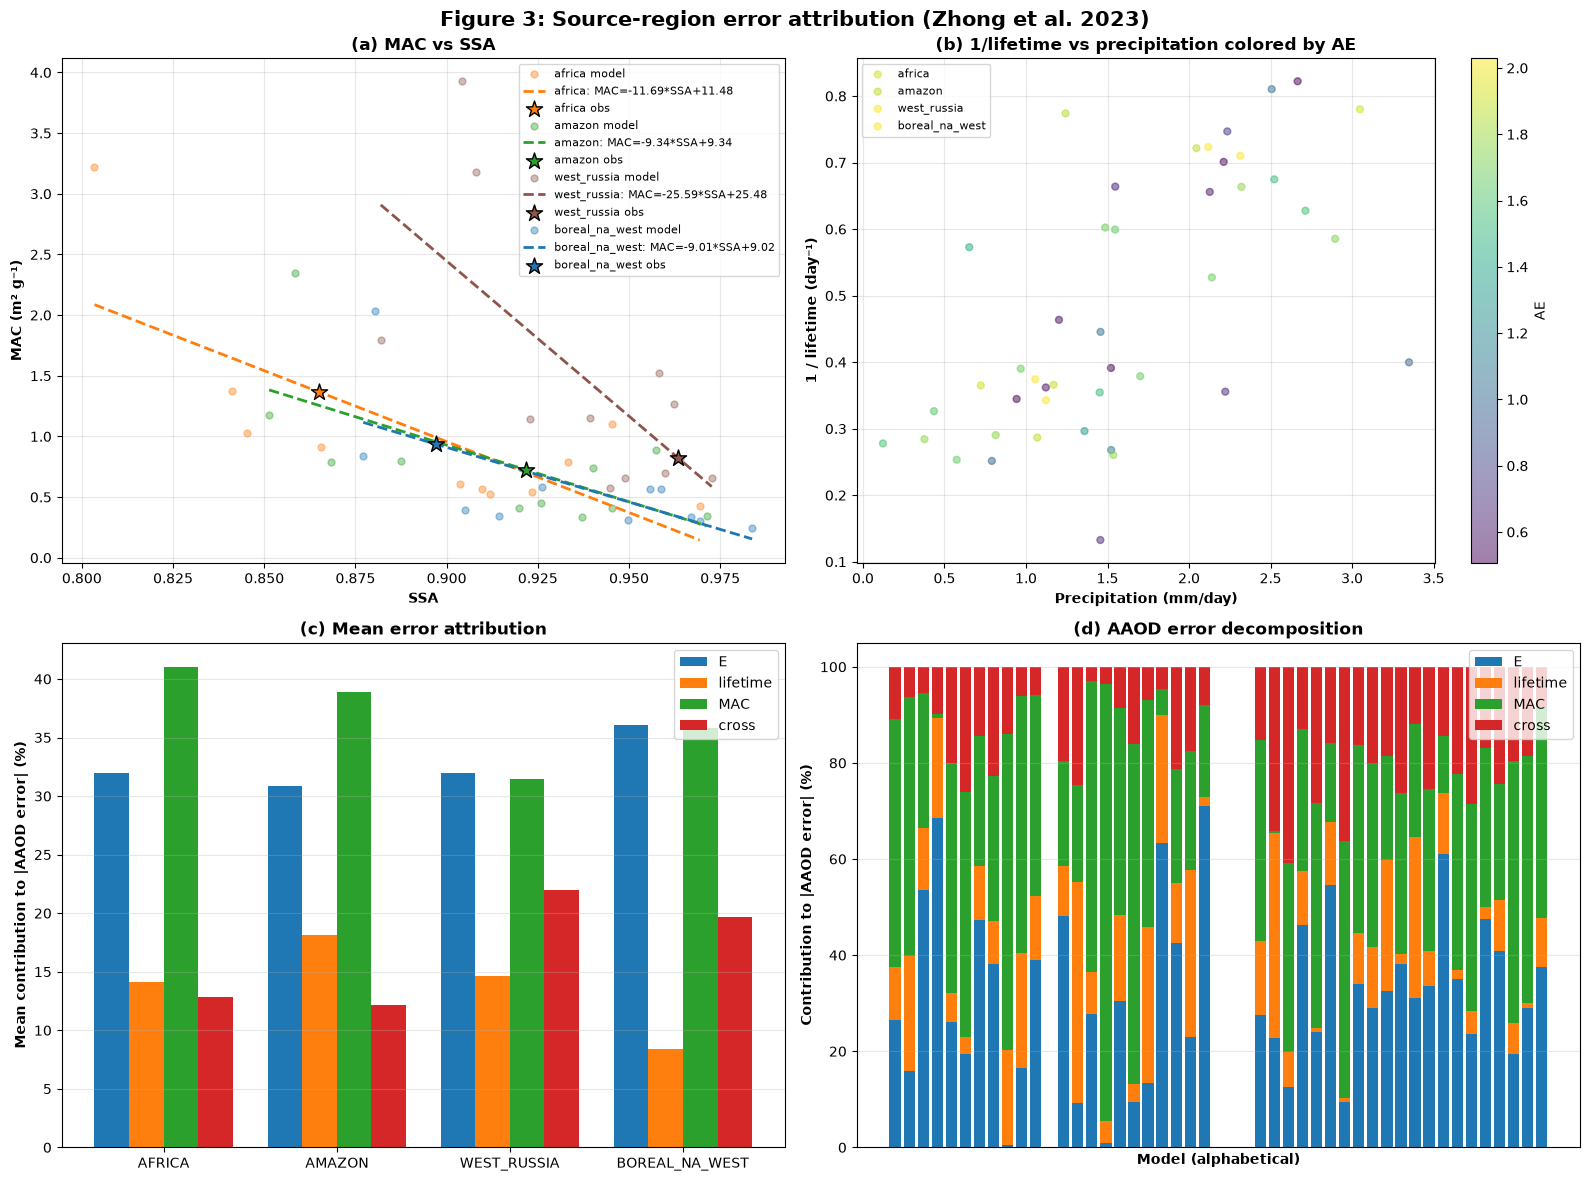

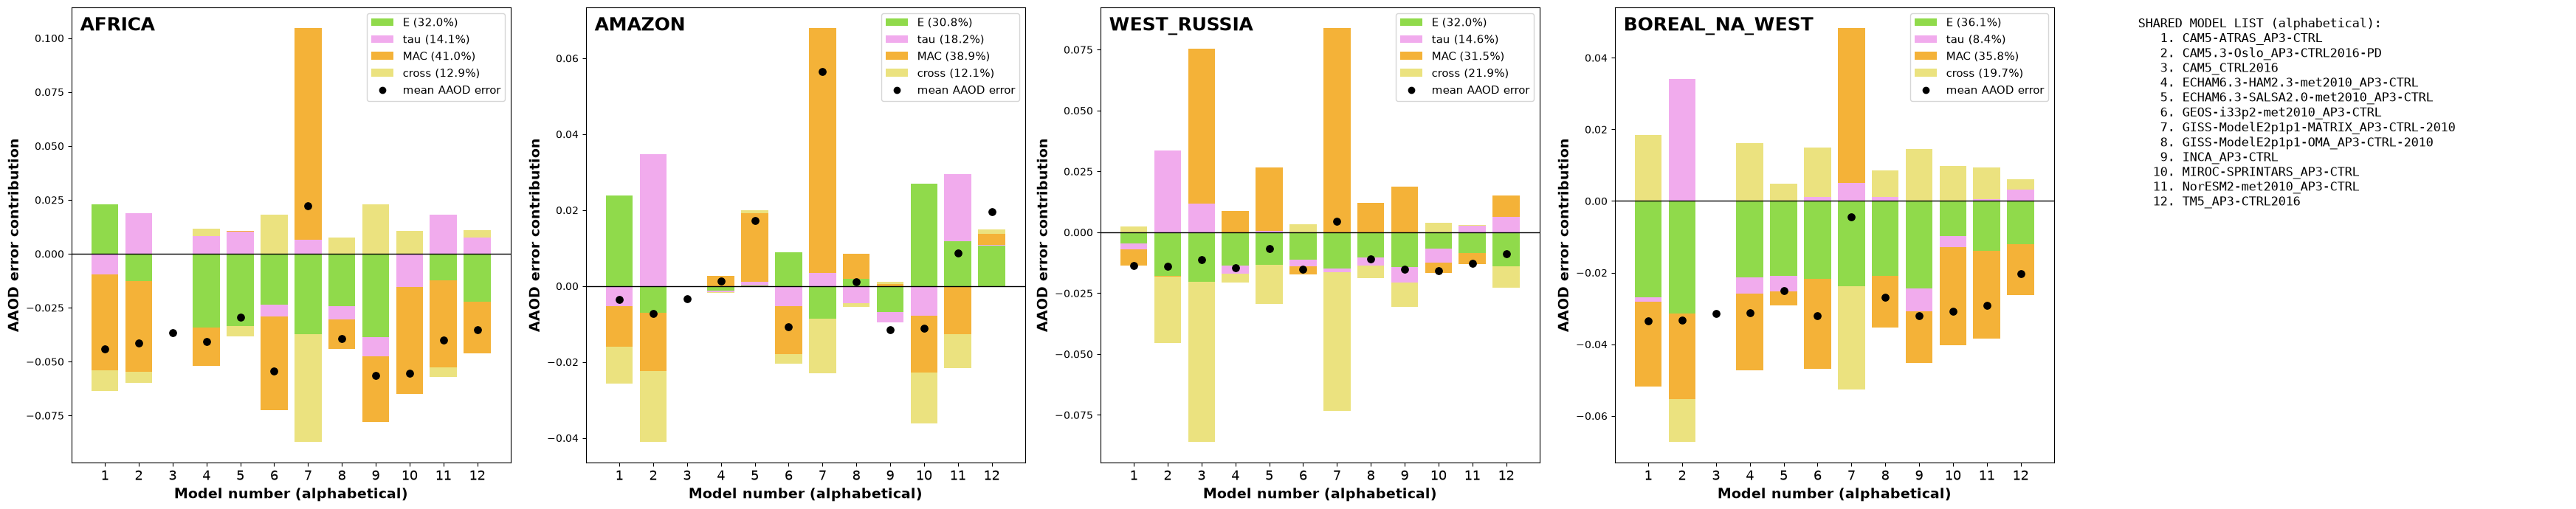

In [18]:
print('\n--- Figure 3 plots (source regions) ---')
# Models are numbered in alphabetical order for the error attribution plots.
colors = REGION_COLORS  # shared per-region palette (see cell 1 config)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) MAC vs SSA
ax = axes[0, 0]
for region in SOURCE_REGIONS:
    if region not in mac_ssa_results:
        continue
    sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', 'SSA'])
    if sub.empty:
        continue
    ax.scatter(sub['SSA'], sub['MAC'], s=25, alpha=0.4, color=colors[region], label=f'{region} model')
    F = mac_ssa_results[region]['F']
    b = mac_ssa_results[region].get('b', 0.0)
    x_line = np.linspace(sub['SSA'].min(), sub['SSA'].max(), 100)
    ax.plot(x_line, F * x_line + b, '--', color=colors[region], linewidth=2,
            label=f'{region}: MAC={F:.2f}*SSA' + (f'+{b:.2f}' if abs(b) > 1e-12 else ''))
    csub = constrained_df[constrained_df['region'] == region]
    if not csub.empty:
        ax.scatter(csub['SSA_obs'].mean(), csub['MAC_c'].mean(), s=150, marker='*',
                   color=colors[region], edgecolors='black', zorder=5, label=f'{region} obs')
ax.set_xlabel('SSA', fontweight='bold')
ax.set_ylabel('MAC (m² g⁻¹)', fontweight='bold')
ax.set_title('(a) MAC vs SSA', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# (b) 1/lifetime vs precip
ax = axes[0, 1]
sc = None
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip', 'AE'])
    if sub.empty:
        continue
    sc = ax.scatter(sub['precip'], sub['inv_lifetime'], c=sub['AE'], cmap='viridis',
                    s=25, alpha=0.5, label=region)
if sc is not None:
    plt.colorbar(sc, ax=ax, label='AE')
ax.set_xlabel('Precipitation (mm/day)', fontweight='bold')
ax.set_ylabel('1 / lifetime (day⁻¹)', fontweight='bold')
ax.set_title('(b) 1/lifetime vs precipitation colored by AE', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# (c) Mean percentage contributions
ax = axes[1, 0]
plot_regions = [r for r in SOURCE_REGIONS if not decomp_df[decomp_df['region'] == r].empty]
x = np.arange(len(plot_regions))
width = 0.2
for i, (col, label, color) in enumerate([
    ('pct_E', 'E', '#1f77b4'),
    ('pct_tau', 'lifetime', '#ff7f0e'),
    ('pct_MAC', 'MAC', '#2ca02c'),
    ('pct_cross', 'cross', '#d62728'),
]):
    vals = [decomp_df[decomp_df['region'] == r][col].mean() for r in plot_regions]
    ax.bar(x + (i - 1.5) * width, vals, width, label=label, color=color)
ax.set_xticks(x)
ax.set_xticklabels([r.upper() for r in plot_regions])
ax.set_ylabel('Mean contribution to |AAOD error| (%)', fontweight='bold')
ax.set_title('(c) Mean error attribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# (d) Per-model stacked percentages (models in alphabetical order)
ax = axes[1, 1]
for idx, region in enumerate(plot_regions):
    sub = decomp_df[decomp_df['region'] == region].sort_values('model', ascending=True)
    if sub.empty:
        continue
    n = len(sub)
    xpos = np.arange(n) + idx * (n + 1)
    ax.bar(xpos, sub['pct_E'], label='E' if idx == 0 else '', color='#1f77b4')
    ax.bar(xpos, sub['pct_tau'], bottom=sub['pct_E'], label='lifetime' if idx == 0 else '', color='#ff7f0e')
    ax.bar(xpos, sub['pct_MAC'], bottom=sub['pct_E'] + sub['pct_tau'],
           label='MAC' if idx == 0 else '', color='#2ca02c')
    ax.bar(xpos, sub['pct_cross'], bottom=sub['pct_E'] + sub['pct_tau'] + sub['pct_MAC'],
           label='cross' if idx == 0 else '', color='#d62728')
ax.set_ylabel('Contribution to |AAOD error| (%)', fontweight='bold')
ax.set_xlabel('Model (alphabetical)', fontweight='bold')
ax.set_title('(d) AAOD error decomposition', fontweight='bold')
ax.set_xticks([])
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Figure 3: Source-region error attribution (Zhong et al. 2023)', fontsize=15, fontweight='bold')
plt.tight_layout()
fig_path = project_root / 'notebooks' / 'figure3_error_attribution.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
    plt.close(fig)


# Per-region signed error bars (Fig. 3 detail); shared alphabetical model list
plot_regions = SOURCE_REGIONS
fig, axes = plt.subplots(1, len(plot_regions) + 1, figsize=(7 * (len(plot_regions) + 1), 7))
common_model_list = sorted(decomp_df['model'].unique().tolist())
for idx, region in enumerate(plot_regions):
    ax = axes[idx]
    sub = decomp_df[decomp_df['region'] == region].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    # Align all regions to the same alphabetical model order
    sub = sub.set_index('model').reindex(common_model_list).reset_index()

    model_aod = aggregate_region(data_derived, 'abs550aer', region, return_time_series=False)
    obs_aod_mean = float(aaod_obs_by_region.get(region, np.nan))
    sub['AAOD_error'] = sub['model'].map(
        lambda m: float(model_aod[m]) - obs_aod_mean if m in model_aod else np.nan
    )
    x = np.arange(len(sub))
    pos_bottom = np.zeros(len(sub))
    neg_bottom = np.zeros(len(sub))
    pct_E_mean = sub['pct_E'].mean()
    pct_tau_mean = sub['pct_tau'].mean()
    pct_MAC_mean = sub['pct_MAC'].mean()
    pct_cross_mean = sub['pct_cross'].mean()
    components = [
        ('dAAOD_E', f'E ({pct_E_mean:.1f}%)', '#90da4b'),
        ('dAAOD_tau', f'tau ({pct_tau_mean:.1f}%)', '#f1abed'),
        ('dAAOD_MAC', f'MAC ({pct_MAC_mean:.1f}%)', '#f4b238'),
        ('dAAOD_cross', f'cross ({pct_cross_mean:.1f}%)', '#ebe27f'),
    ]
    for col, label, color in components:
        vals = sub[col].to_numpy(dtype=float)
        bottoms = np.where(vals >= 0, pos_bottom, neg_bottom)
        ax.bar(x, vals, bottom=bottoms, color=color, width=0.8)
        pos_bottom = np.where(vals >= 0, pos_bottom + vals, pos_bottom)
        neg_bottom = np.where(vals < 0, neg_bottom + vals, neg_bottom)
    ax.scatter(x, sub['AAOD_error'], color='black', s=45, zorder=5)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(np.arange(1, len(sub) + 1), fontsize=13)
    ax.set_ylabel('AAOD error contribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model number (alphabetical)', fontsize=14, fontweight='bold')
    ax.text(0.02, 0.98, region.upper(), transform=ax.transAxes, va='top', ha='left',
            fontsize=18, fontweight='bold')
    ax.legend(handles=[
        Patch(facecolor='#90da4b', label=f'E ({pct_E_mean:.1f}%)'),
        Patch(facecolor='#f1abed', label=f'tau ({pct_tau_mean:.1f}%)'),
        Patch(facecolor='#f4b238', label=f'MAC ({pct_MAC_mean:.1f}%)'),
        Patch(facecolor='#ebe27f', label=f'cross ({pct_cross_mean:.1f}%)'),
        Line2D([0], [0], marker='o', color='black', linestyle='None', label='mean AAOD error'),
    ], loc='upper right', fontsize=11)

ax_legend = axes[-1]
ax_legend.axis('off')
legend_lines = ['SHARED MODEL LIST (alphabetical):']
for i, model in enumerate(common_model_list or [], start=1):
    legend_lines.append(f'  {i:>2d}. {model}')
ax_legend.text(0.02, 0.98, '\n'.join(legend_lines), transform=ax_legend.transAxes,
               va='top', ha='left', fontsize=12, family='monospace')
plt.tight_layout()
fig_path = project_root / 'notebooks' / 'figure3_error_attribution_by_region.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
    plt.close(fig)


## rBC vs modeled SSA (cf. Fig. S6, Zhong et al. 2023)

rBC = BC:(BC+OA) column-load mass ratio, plotted against modeled SSA per
model/region (seasonal means). Zhong et al. (2023) Fig. S6 overlays an
in-situ observed SSA-rBC relationship from Brown et al. (2021, *Nat.
Commun.*, "Biomass burning aerosols in most climate models are too
absorbing"). **That in-situ regression line is NOT reproduced below**:
its numeric coefficients are not available anywhere in this repository's
literature extracts (`literature/sciadv.adi3568*.pdf`), and are not
fabricated here -- only the modeled rBC-SSA relationship is shown.

In [ ]:
print('\n--- rBC vs modeled SSA (cf. Fig. S6) ---')
# loadbc/loadoa are raw NetCDF variables (VARIABLES list, cell 3) but are not
# part of `variables_pre_aggregated` (cell 7 derived-vars cell), so they were
# never aggregated into `model_seasonal`. Aggregate them here directly with
# the same `aggregate_region` helper used to build `model_seasonal` (cell 9).
loadbc_by_region = {region: aggregate_region(data_derived, 'loadbc', region) for region in SOURCE_REGIONS}
loadoa_by_region = {region: aggregate_region(data_derived, 'loadoa', region) for region in SOURCE_REGIONS}

rbc_rows = []
for region in SOURCE_REGIONS:
    loadbc = loadbc_by_region[region]
    loadoa = loadoa_by_region[region]
    ssa = model_seasonal[region].get('SSA', {})
    for model in set(loadbc) & set(loadoa) & set(ssa):
        try:
            bc = float(loadbc[model])
            oa = float(loadoa[model])
            s = float(ssa[model])
        except (TypeError, ValueError):
            continue
        if not (np.isfinite(bc) and np.isfinite(oa) and np.isfinite(s)):
            continue
        denom = bc + oa
        if denom <= 0:
            continue
        rbc_rows.append({'region': region, 'model': model, 'rBC': bc / denom, 'SSA': s})
rbc_df = pd.DataFrame(rbc_rows, columns=['region', 'model', 'rBC', 'SSA'])
print(f'  rBC/SSA rows: {len(rbc_df)} (regions: {sorted(rbc_df["region"].unique()) if not rbc_df.empty else []})')

fig, ax = plt.subplots(figsize=(8, 7))
rbc_ssa_results = {}
for region in SOURCE_REGIONS:
    sub = rbc_df[rbc_df['region'] == region]
    if sub.empty:
        continue
    color = REGION_COLORS.get(region, 'tab:blue')
    ax.scatter(sub['rBC'], sub['SSA'], s=45, alpha=0.65, color=color, edgecolors='black',
               linewidths=0.3, label=f'{region} (n={len(sub)})')
    if len(sub) >= 3:
        slope, intercept, r, p, se = linregress(sub['rBC'], sub['SSA'])
        rbc_ssa_results[region] = {'slope': slope, 'intercept': intercept, 'r2': r ** 2, 'p': p, 'n': len(sub)}
        x_line = np.linspace(sub['rBC'].min(), sub['rBC'].max(), 50)
        ax.plot(x_line, slope * x_line + intercept, '--', color=color, linewidth=2)
        print(f'  {region}: SSA = {slope:.3f}*rBC + {intercept:.3f}  '
              f'(R^2={r ** 2:.3f}, p={p:.3g}, n={len(sub)})')
    else:
        print(f'  {region}: too few points ({len(sub)}) for regression')

ax.set_xlabel('rBC = loadbc / (loadbc + loadoa)', fontweight='bold')
ax.set_ylabel('Modeled SSA', fontweight='bold')
ax.set_title('Modeled SSA vs rBC (cf. Fig. S6, Zhong et al. 2023)', fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='upper right')
ax.text(
    0.02, 0.02,
    'Note: Brown et al. (2021) in-situ SSA-rBC reference relationship is NOT '
    'shown here -- its regression coefficients are not available in this '
    "repository's literature extracts and are not fabricated.",
    transform=ax.transAxes, fontsize=8, va='bottom', ha='left',
    style='italic', color='dimgray',
)
plt.tight_layout()
fig_path = project_root / 'notebooks' / 'rbc_vs_ssa.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
plt.close(fig)



--- rBC vs modeled SSA (cf. Fig. S6) ---
  rBC/SSA rows: 60 (regions: ['africa', 'amazon', 'boreal_na_west', 'west_russia'])
  africa: SSA = -1.218*rBC + 0.976  (R^2=0.305, p=0.0328, n=15)
  amazon: SSA = -0.904*rBC + 0.962  (R^2=0.261, p=0.0515, n=15)
  west_russia: SSA = -0.517*rBC + 0.971  (R^2=0.294, p=0.0367, n=15)
  boreal_na_west: SSA = -1.614*rBC + 0.988  (R^2=0.230, p=0.0702, n=15)


## Figure 2 style: modeled MAC vs SSA (parametrized, cf. Zhong et al. 2023 Fig. 2)

Reusable `plot_mac_vs_ssa(plot_regions, ...)`: one panel per region, model
scatter + OLS fit (from `mac_ssa_results`), a vertical dashed line at the
regional (homogenized) SSA_obs, a horizontal dashed line at the constrained
MAC_c, and their intersection (star marker). Called once with the paper's
two regions (`amazon`, `africa`) and once with all `SOURCE_REGIONS`.

In [ ]:
def plot_mac_vs_ssa(plot_regions, title_suffix=''):
    """Fig. 2 style panel(s): MAC vs SSA per model, one subplot per region.

    Parameters
    ----------
    plot_regions : list[str]
        Region keys (must exist in ``REGIONS``/``mac_ssa_results``).
    title_suffix : str
        Appended to the figure title (e.g. to distinguish paper-region vs.
        extended-region calls).
    """
    n = len(plot_regions)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), squeeze=False)
    axes = axes[0]
    for ax, region in zip(axes, plot_regions):
        sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', 'SSA'])
        color = REGION_COLORS.get(region, 'tab:blue')
        if sub.empty or region not in mac_ssa_results:
            ax.text(0.5, 0.5, 'no regression\n(insufficient data)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(region.upper(), fontweight='bold')
            continue
        ax.scatter(sub['SSA'], sub['MAC'], s=40, alpha=0.55, color=color,
                   edgecolors='black', linewidths=0.3, label='models')
        F = mac_ssa_results[region]['F']
        b = mac_ssa_results[region].get('b', 0.0)
        r2 = mac_ssa_results[region]['r2']
        x_line = np.linspace(sub['SSA'].min(), sub['SSA'].max(), 100)
        fit_label = f'OLS: MAC={F:.2f}*SSA' + (f'+{b:.2f}' if abs(b) > 1e-12 else '') + f' ($R^2$={r2:.2f})'
        ax.plot(x_line, F * x_line + b, '-', color='black', linewidth=2, label=fit_label)
        csub = constrained_df[constrained_df['region'] == region]
        if not csub.empty:
            ssa_obs = float(csub['SSA_obs'].mean())
            mac_c = float(csub['MAC_c'].mean())
            ax.axvline(ssa_obs, color='gray', linestyle='--', linewidth=1.5,
                       label=f'SSA_obs={ssa_obs:.3f}')
            ax.axhline(mac_c, color='crimson', linestyle=':', linewidth=1.5,
                       label=f'MAC_c={mac_c:.2f}')
            ax.scatter([ssa_obs], [mac_c], marker='*', s=200, color=color,
                       edgecolors='black', zorder=6, label='constrained')
        ax.set_xlabel('SSA', fontweight='bold')
        ax.set_ylabel('MAC (m$^2$ g$^{-1}$)', fontweight='bold')
        ax.set_title(region.upper(), fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'Figure 2 style: modeled MAC vs SSA{title_suffix}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    return fig


print('\n--- Fig. 2 style MAC vs SSA: paper regions (amazon, africa) ---')
_fig2_paper_regions = [r for r in ['amazon', 'africa'] if r in SOURCE_REGIONS]
fig_2_paper = plot_mac_vs_ssa(_fig2_paper_regions, ' (paper regions)')
if SAVE_FIGURE:
    fig_2_paper.savefig(project_root / 'notebooks' / 'fig2_mac_vs_ssa_paper.png', dpi=300, bbox_inches='tight')
    print('Saved: fig2_mac_vs_ssa_paper.png')
    plt.close(fig_2_paper)

print('\n--- Fig. 2 style MAC vs SSA: all source regions (extended) ---')
fig_2_all = plot_mac_vs_ssa(SOURCE_REGIONS, ' (all source regions)')
if SAVE_FIGURE:
    fig_2_all.savefig(project_root / 'notebooks' / 'fig2_mac_vs_ssa_all_regions.png', dpi=300, bbox_inches='tight')
    print('Saved: fig2_mac_vs_ssa_all_regions.png')
    plt.close(fig_2_all)



--- Fig. 2 style MAC vs SSA: paper regions (amazon, africa) ---

--- Fig. 2 style MAC vs SSA: all source regions (extended) ---


## Outflow prediction plot: model vs meta-fit vs constrained vs POLDER



--- Outflow prediction plot ---
  Outflow meta-model R²=0.973, NMB=-0.0%, RMSE=0.00274


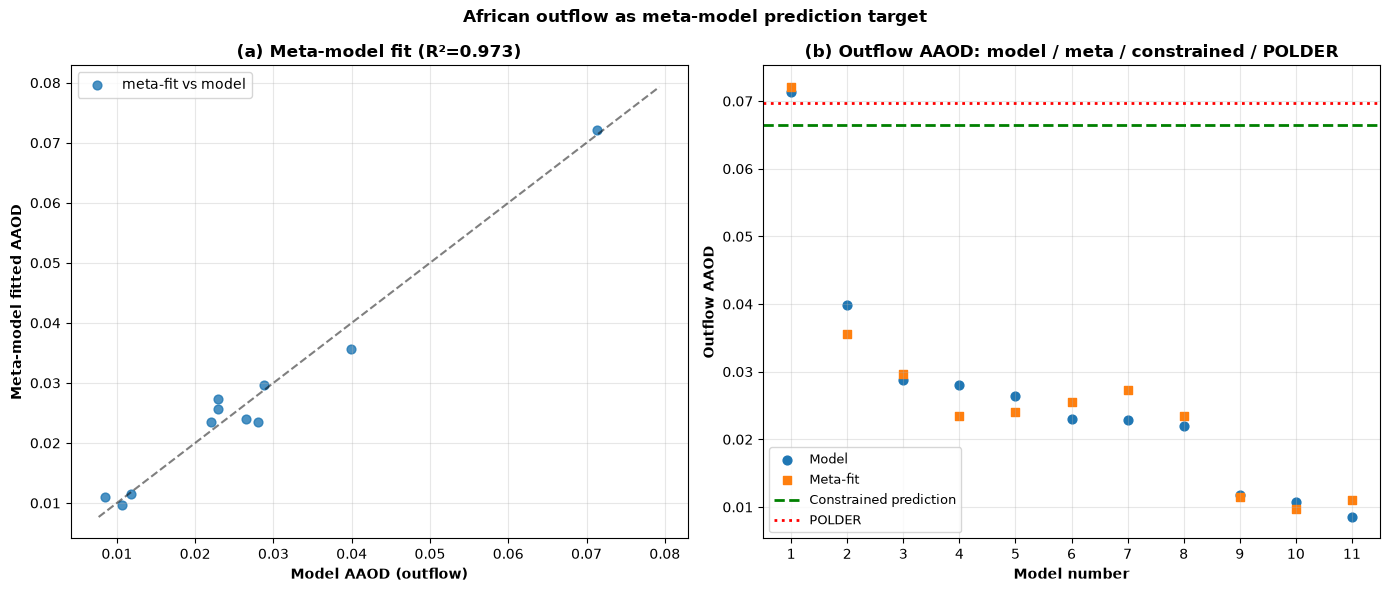

In [ ]:
print('\n--- Outflow prediction plot ---')
if outflow_pred_df.empty:
    print('  No outflow predictions to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(outflow_pred_df['AAOD_model'], outflow_pred_df['AAOD_meta_fit'],
               s=40, alpha=0.8, label='meta-fit vs model')
    lims = [
        min(outflow_pred_df['AAOD_model'].min(), outflow_pred_df['AAOD_meta_fit'].min()) * 0.9,
        max(outflow_pred_df['AAOD_model'].max(), outflow_pred_df['AAOD_meta_fit'].max()) * 1.1,
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Model AAOD (outflow)', fontweight='bold')
    ax.set_ylabel('Meta-model fitted AAOD', fontweight='bold')
    title_r2 = outflow_meta_params['r2'] if outflow_meta_params else np.nan
    ax.set_title(f'(a) Meta-model fit (R²={title_r2:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    sub = outflow_pred_df.sort_values('model', ascending=True).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.scatter(x, sub['AAOD_model'], label='Model', s=40)
    ax.scatter(x, sub['AAOD_meta_fit'], label='Meta-fit', s=40, marker='s')
    ax.axhline(sub['AAOD_constrained'].iloc[0], color='green', linestyle='--',
               linewidth=2, label='Constrained prediction')
    ax.axhline(sub['AAOD_obs'].iloc[0], color='red', linestyle=':',
               linewidth=2, label='POLDER')
    ax.set_xticks(x)
    ax.set_xticklabels(np.arange(1, len(sub) + 1))
    ax.set_xlabel('Model number (alphabetical)', fontweight='bold')
    ax.set_ylabel('Outflow AAOD', fontweight='bold')
    ax.set_title('(b) Outflow AAOD: model / meta / constrained / POLDER', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle('African outflow as meta-model prediction target', fontweight='bold')
    plt.tight_layout()
    fig_path = project_root / 'notebooks' / 'figure3_outflow_meta_prediction.png'
    if SAVE_FIGURE:
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {fig_path}')
        plt.close(fig)
        

    if outflow_meta_params:
        print(f"  Outflow meta-model R²={outflow_meta_params['r2']:.3f}, "
              f"NMB={outflow_meta_params['nmb']:.1f}%, RMSE={outflow_meta_params['rmse']:.5f}")


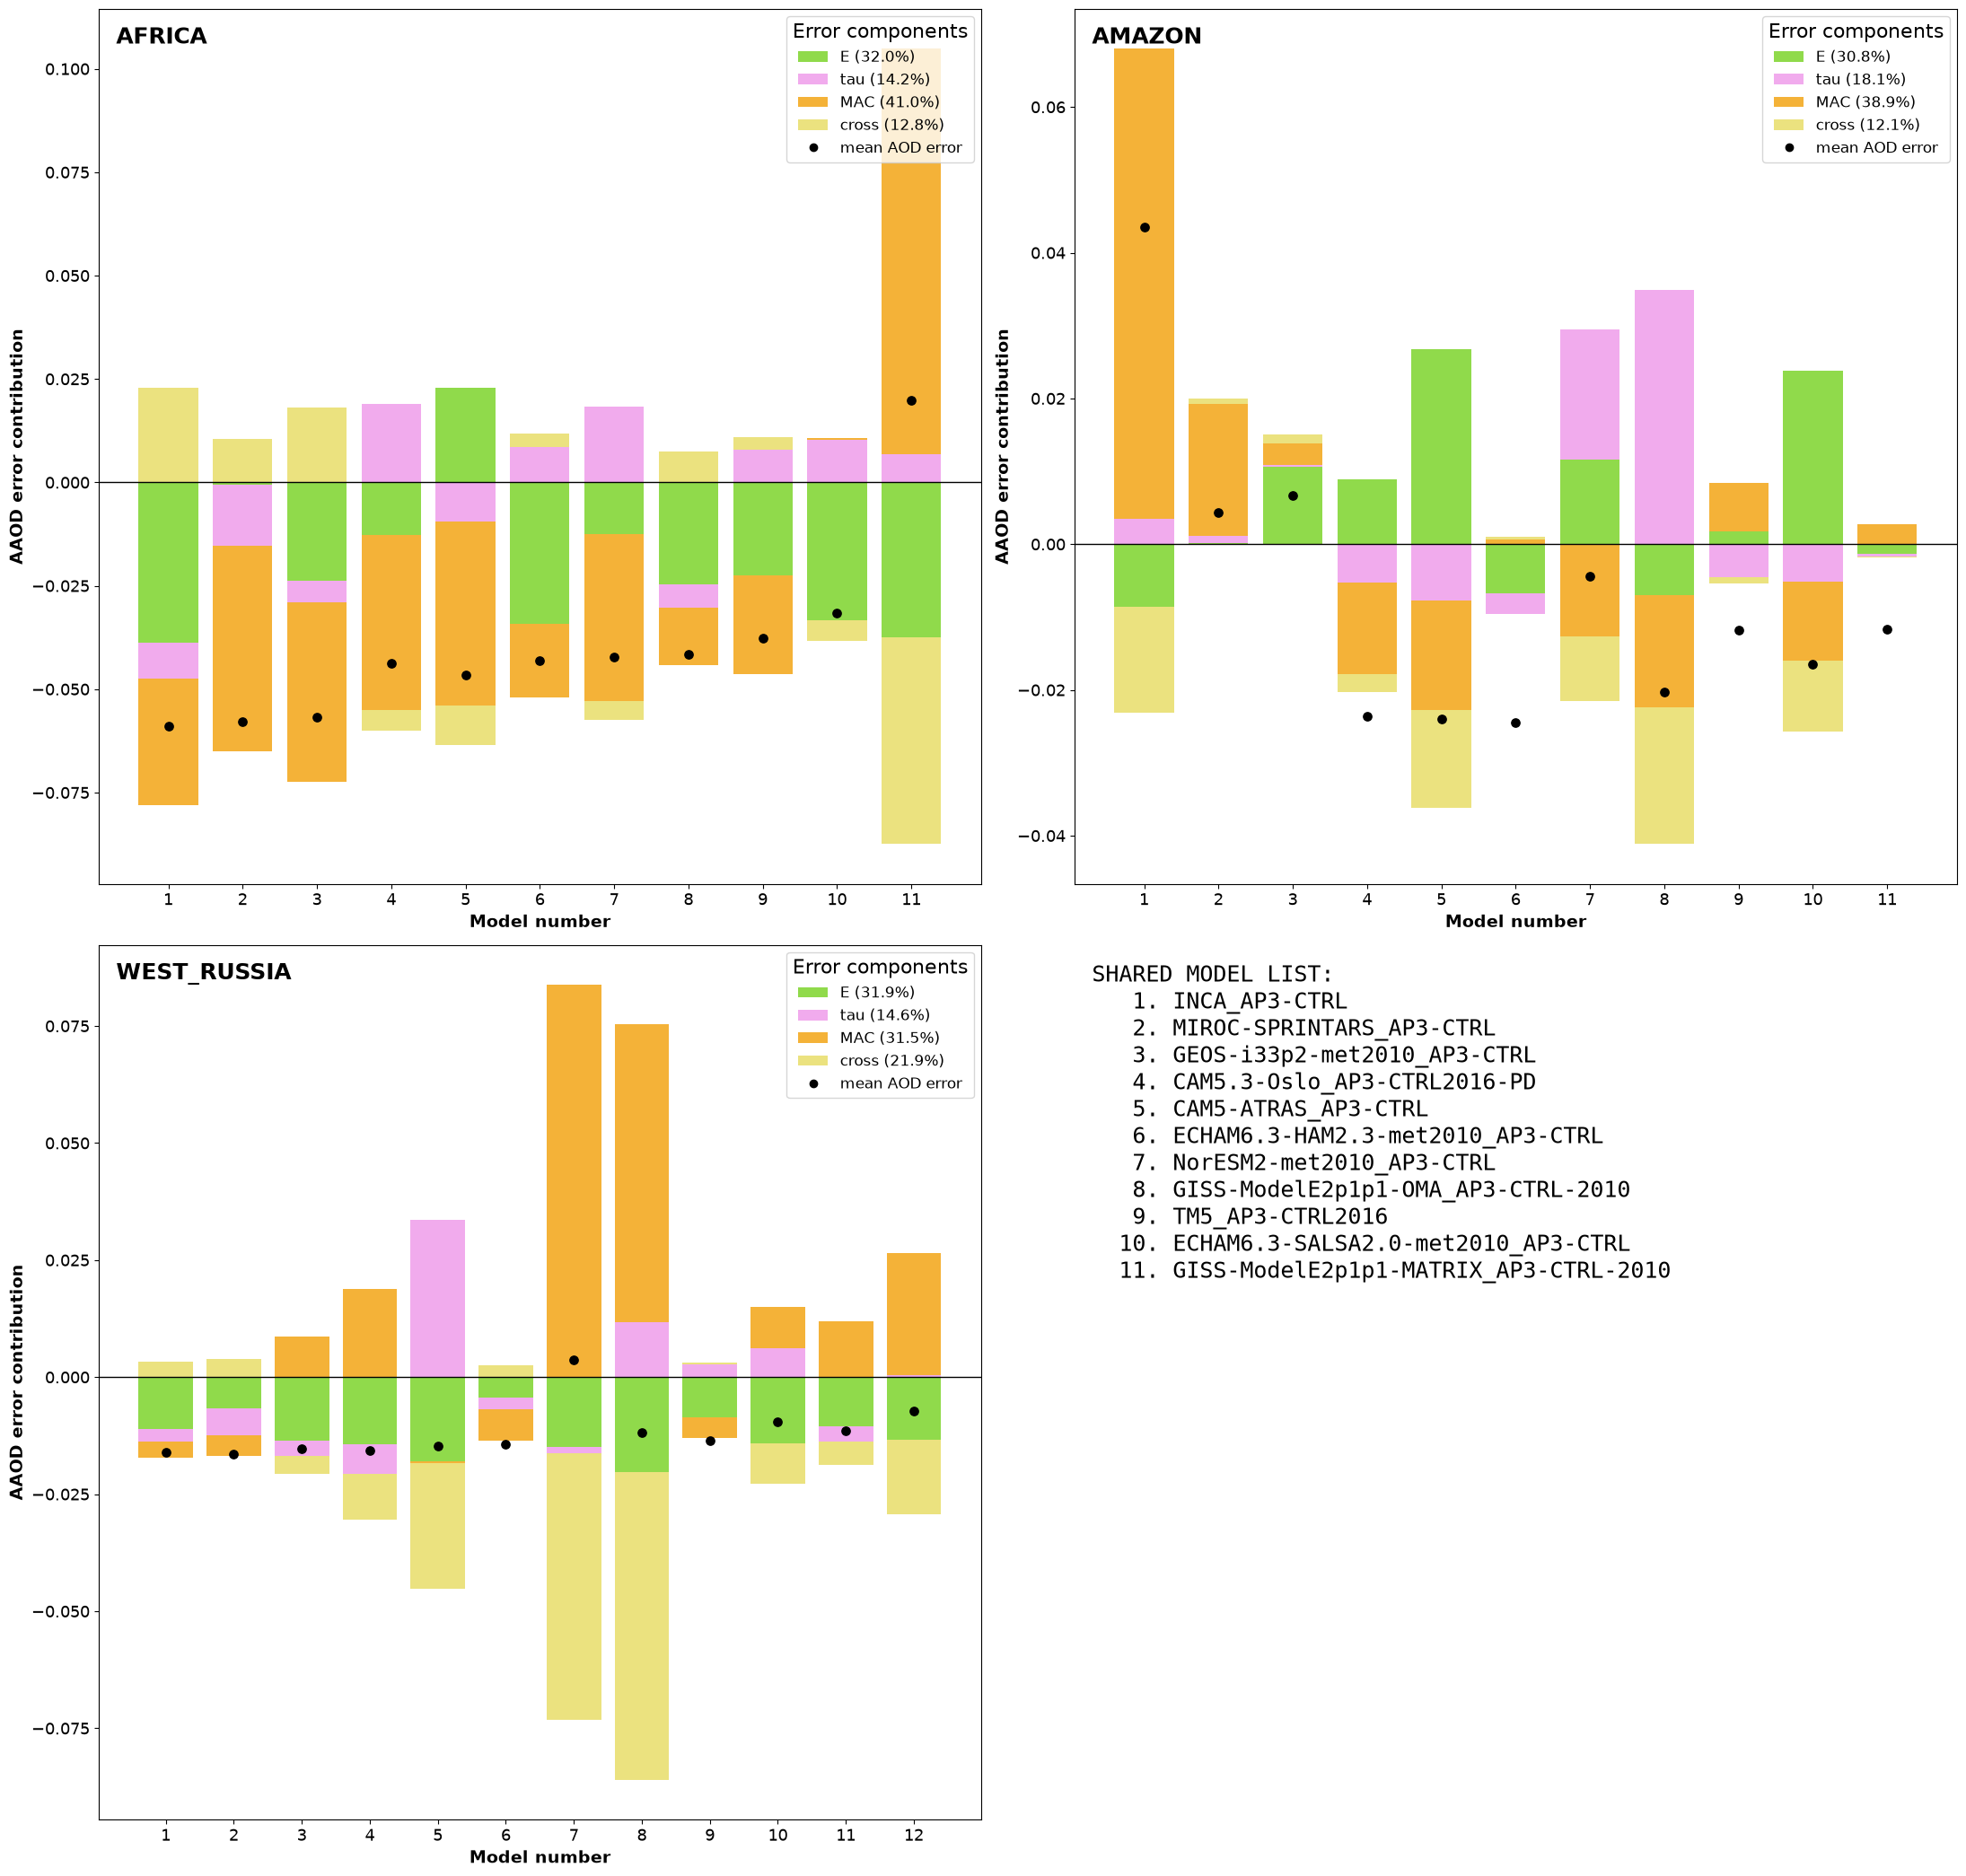

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_regions = ['africa', 'amazon', 'west_russia']

fig, axes = plt.subplots(2, 2, figsize=(22, 7 * len(plot_regions)))

axes_flat = axes.flatten()
common_model_list = sorted(decomp_df['model'].unique().tolist())

for idx, region in enumerate(plot_regions):
    ax = axes_flat[idx]
    sub = decomp_df[decomp_df['region'] == region].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    # Align all regions to the same alphabetical model order
    sub = sub.set_index('model').reindex(common_model_list).reset_index()

    # Seasonal mean AOD error per model relative to POLDER
    model_aod = aggregate_region(data_derived, 'abs550aer', region, return_time_series=False)
    obs_aod_mean = polder_monthly[region]['AAOD_550'].mean() if not polder_monthly[region].empty else np.nan
    sub['AAOD_error'] = sub['model'].map(
        lambda m: float(model_aod[m]) - obs_aod_mean if (m in model_aod and pd.notna(obs_aod_mean)) else np.nan
    )

    x = np.arange(len(sub))

    # Signed stacking
    pos_bottom = np.zeros(len(sub))
    neg_bottom = np.zeros(len(sub))

    pct_E_mean = sub['pct_E'].mean()
    pct_tau_mean = sub['pct_tau'].mean()
    pct_MAC_mean = sub['pct_MAC'].mean()
    pct_cross_mean = sub['pct_cross'].mean()

    components = [
        ('dAAOD_E', f"E ({pct_E_mean:.1f}%)", "#90da4b"),
        ('dAAOD_tau', f"tau ({pct_tau_mean:.1f}%)", "#f1abed"),
        ('dAAOD_MAC', f"MAC ({pct_MAC_mean:.1f}%)", "#f4b238"),
        ('dAAOD_cross', f"cross ({pct_cross_mean:.1f}%)", "#ebe27f"),
    ]

    for col, label, color in components:
        vals = sub[col].to_numpy(dtype=float)
        bottoms = np.where(vals >= 0, pos_bottom, neg_bottom)
        ax.bar(x, vals, bottom=bottoms, color=color, width=0.8)

        pos_bottom = np.where(vals >= 0, pos_bottom + vals, pos_bottom)
        neg_bottom = np.where(vals < 0, neg_bottom + vals, neg_bottom)

    ax.scatter(x, sub['AAOD_error'], color='black', s=45, zorder=5)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(np.arange(1, len(sub) + 1), fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.set_ylabel('AAOD error contribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model number (alphabetical)', fontsize=14, fontweight='bold')
    ax.text(
        0.02, 0.98, region.upper(),
        transform=ax.transAxes, va='top', ha='left',
        fontsize=18, fontweight='bold'
    )

    legend_handles = [
        Patch(facecolor='#90da4b', label=f'E ({pct_E_mean:.1f}%)'),
        Patch(facecolor='#f1abed', label=f'tau ({pct_tau_mean:.1f}%)'),
        Patch(facecolor='#f4b238', label=f'MAC ({pct_MAC_mean:.1f}%)'),
        Patch(facecolor='#ebe27f', label=f'cross ({pct_cross_mean:.1f}%)'),
        Line2D([0], [0], marker='o', color='black', linestyle='None', label='mean AOD error'),
    ]
    ax.legend(
        handles=legend_handles, loc='upper right',
        fontsize=12, title='Error components', title_fontsize=16,
        frameon=True
    )

# Model-name panel in row 2, col 2 (shared list shown once)
ax_legend = axes_flat[3]
ax_legend.axis('off')

legend_lines = ['SHARED MODEL LIST (alphabetical):']
for i, model in enumerate(common_model_list or [], start=1):
    legend_lines.append(f'  {i:>2d}. {model}')

ax_legend.text(
    0.02, 0.98, '\n'.join(legend_lines).strip(),
    transform=ax_legend.transAxes, va='top', ha='left',
    fontsize=18, family='monospace'
)

plt.tight_layout()
fig_path = project_root / 'notebooks' / 'figure3_error_attribution_by_region.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
    plt.close()

## OMI HCHO columns vs AOD/SSA (Fig. 4 style)

Daily area-weighted regional OMI HCHO (formaldehyde) column, quality-filtered
(`data_quality_flag == 0`), collocated with daily POLDER AOD/SSA for Amazon and
Southern Africa (cf. Zhong et al. 2023 Fig. 4C/D: AOD-HCHO and SSA-HCHO
correlations support the paper's SOA-formation narrative).

**Data-availability caveat (checked directly against files on disk):**
`Data/OMI_HCHO/` only contains daily files for **2010 Jan-Apr (and 2008 Jan)**;
none of the region `time_slice` windows used here (all Jun-Oct, the 2010
biomass-burning seasons) are covered. The code below is fully general and will
produce the Fig. 4-style scatter automatically once matching-season OMI HCHO
files are added, but with the data currently present it can only report zero
collocated days -- this is reported explicitly rather than silently producing
an empty or misleading plot.

In [ ]:
def polder_daily_means(df, region_name):
    """Area-weighted daily regional means from POLDER 3-hourly data.

    Parallels ``polder_monthly_means`` but aggregates to daily resolution,
    needed to collocate with daily OMI HCHO columns (item 7 / Fig. 4 style).
    """
    cfg = REGIONS[region_name]
    mask = polder_region_mask(df, cfg['lon_range'], cfg['lat_range'])
    sub = df[mask].copy()
    t0, t1 = cfg['time_slice']
    sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
    if sub.empty:
        return pd.DataFrame()
    sub['date'] = sub['time'].dt.floor('D')
    sub['coslat'] = np.cos(np.deg2rad(sub['latitude']))
    rows = []
    for date, g in sub.groupby('date'):
        if len(g) < 3:
            continue
        w = g['coslat']
        rows.append({
            'date': date,
            'SSA': np.average(g['SSA'], weights=w),
            'AOD_550': np.average(g['AOD_550'], weights=w),
            'AAOD_550': np.average(g['AAOD_550'], weights=w),
            'n': len(g),
        })
    return pd.DataFrame(rows)


def load_omi_hcho_daily_region(region_name, years=(2008, 2010)):
    """Load daily OMI HCHO column_amount, quality-filtered, area-weighted regional mean.

    OMI-Aura L3 OMHCHOd files: root group has 1-D ``longitude``
    (-180..180 convention) / ``latitude`` coords; actual data variables live in
    HDF5 sub-groups ``key_science_data`` (``column_amount``) and
    ``qa_statistics`` (``data_quality_flag``, 0=good).
    """
    cfg = REGIONS[region_name]
    lon_min, lon_max = cfg['lon_range']
    lat_min, lat_max = cfg['lat_range']
    t0, t1 = pd.Timestamp(cfg['time_slice'][0]), pd.Timestamp(cfg['time_slice'][1])
    # Region lon bounds are in 0-360 convention; OMI files use -180..180.
    lon_min_180 = lon_min - 360 if lon_min > 180 else lon_min
    lon_max_180 = lon_max - 360 if lon_max > 180 else lon_max

    rows = []
    for year in years:
        year_dir = project_root / 'Data' / 'OMI_HCHO' / str(year)
        if not year_dir.exists():
            continue
        for fpath in sorted(year_dir.glob('OMI-Aura_L3-OMHCHOd_*.nc')):
            try:
                datestr = fpath.name.split('_')[2]  # 'YYYYmMMDD'
                date = pd.Timestamp(f'{datestr[0:4]}-{datestr[5:7]}-{datestr[7:9]}')
            except Exception:
                continue
            if not (t0 <= date <= t1):
                continue
            try:
                ds_root = xr.open_dataset(fpath)
                lon = ds_root['longitude'].values
                lat = ds_root['latitude'].values
                ds_ksd = xr.open_dataset(fpath, group='key_science_data')
                ds_qa = xr.open_dataset(fpath, group='qa_statistics')
                col = ds_ksd['column_amount'].values
                qa = ds_qa['data_quality_flag'].values
                ds_root.close(); ds_ksd.close(); ds_qa.close()
            except Exception as e:
                print(f'  Failed to read {fpath.name}: {e}')
                continue
            if lon_min_180 > lon_max_180:
                lon_mask = (lon >= lon_min_180) | (lon <= lon_max_180)
            else:
                lon_mask = (lon >= lon_min_180) & (lon <= lon_max_180)
            lat_mask = (lat >= lat_min) & (lat <= lat_max)
            sub = col[np.ix_(lat_mask, lon_mask)]
            qa_sub = qa[np.ix_(lat_mask, lon_mask)]
            good = (qa_sub == 0) & np.isfinite(sub) & (sub > -1e29)
            if good.sum() < 5:
                continue
            latg = lat[lat_mask]
            weights = np.repeat(np.cos(np.deg2rad(latg))[:, None], lon_mask.sum(), axis=1)
            hcho_mean = float(np.average(sub[good], weights=weights[good]))
            rows.append({'date': date, 'HCHO': hcho_mean, 'n_pixels': int(good.sum())})
    return pd.DataFrame(rows)


print('\n--- Fig. 4 style: AOD/SSA vs OMI HCHO ---')

# Report actual on-disk OMI HCHO date coverage vs the region time windows needed.
_omi_dates = []
for _year_dir in sorted((project_root / 'Data' / 'OMI_HCHO').glob('*')):
    if _year_dir.is_dir():
        for _f in _year_dir.glob('OMI-Aura_L3-OMHCHOd_*.nc'):
            _ds = _f.name.split('_')[2]
            _omi_dates.append(pd.Timestamp(f'{_ds[0:4]}-{_ds[5:7]}-{_ds[7:9]}'))
if _omi_dates:
    print(f'  OMI HCHO files on disk: {len(_omi_dates)}, '
          f'covering {min(_omi_dates).date()} to {max(_omi_dates).date()}')
else:
    print('  No OMI HCHO files found on disk.')

hcho_regions = [r for r in ['amazon', 'africa'] if r in REGIONS]
fig, axes = plt.subplots(1, len(hcho_regions), figsize=(7 * len(hcho_regions), 6), squeeze=False)
axes = axes[0]
for ax, region in zip(axes, hcho_regions):
    daily = polder_daily_means(polder_df, region)
    hcho = load_omi_hcho_daily_region(region)
    t0, t1 = REGIONS[region]['time_slice']
    if daily.empty or hcho.empty:
        ax.text(
            0.5, 0.5,
            f'No collocated data.\nRegion time window: {t0} to {t1}\n'
            f'POLDER daily points: {len(daily)}, OMI HCHO daily points: {len(hcho)}\n'
            '(OMI HCHO files on disk do not cover this season -- see markdown note above)',
            ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray', wrap=True,
        )
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(region.upper(), fontweight='bold')
        print(f'  {region}: insufficient data (POLDER daily={len(daily)}, HCHO daily={len(hcho)})')
        continue
    merged = pd.merge(daily, hcho, on='date', how='inner')
    print(f'  {region}: {len(merged)} collocated days')
    if len(merged) < 5:
        ax.text(0.5, 0.5, f'Only {len(merged)} collocated day(s); too few for correlation.',
                ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(region.upper(), fontweight='bold')
        continue
    sc = ax.scatter(merged['HCHO'], merged['AOD_550'], c=merged['SSA'], cmap='viridis',
                    s=45, edgecolors='k', linewidths=0.3)
    r_aod, p_aod = stats.pearsonr(merged['HCHO'], merged['AOD_550'])
    r_ssa, p_ssa = stats.pearsonr(merged['HCHO'], merged['SSA'])
    ax.set_xlabel('OMI HCHO column (molec cm$^{-2}$)', fontweight='bold')
    ax.set_ylabel('POLDER AOD$_{550}$', fontweight='bold')
    ax.set_title(f'{region.upper()}: r(AOD,HCHO)={r_aod:.2f} (p={p_aod:.3f}), '
                 f'r(SSA,HCHO)={r_ssa:.2f} (p={p_ssa:.3f})', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label='SSA')
plt.suptitle('Figure 4 style: daily AOD vs OMI HCHO colored by SSA', fontsize=14, fontweight='bold')
plt.tight_layout()
fig_path = project_root / 'notebooks' / 'fig4_aod_hcho_ssa.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
plt.close(fig)



--- Fig. 4 style: AOD/SSA vs OMI HCHO ---
  OMI HCHO files on disk: 150, covering 2008-01-01 to 2010-05-01
  amazon: insufficient data (POLDER daily=80, HCHO daily=0)
  africa: insufficient data (POLDER daily=77, HCHO daily=0)


## Save CSV outputs


In [ ]:
out_csv = project_root / 'notebooks' / 'figure3_regression_data.csv'
reg_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

out_csv = project_root / 'notebooks' / 'figure3_constrained_estimates.csv'
constrained_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

out_csv = project_root / 'notebooks' / 'figure3_error_decomposition.csv'
decomp_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

if not outflow_pred_df.empty:
    out_csv = project_root / 'notebooks' / 'figure3_outflow_meta_predictions.csv'
    outflow_pred_df.to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

out_csv = project_root / 'notebooks' / 'figure3_model_region_data.csv'
model_region_rows = []
for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
    for model in models:
        row = {'region': region, 'model': model}
        for var in ['MEC', 'MAC', 'SSA', 'AE', 'lifetime_BC_OA', 'precip', 'emi_BC_OA', 'abs550aer']:
            val = model_seasonal[region].get(var, {}).get(model)
            row[var] = float(val) if val is not None and np.isfinite(float(val)) else np.nan
        model_region_rows.append(row)
pd.DataFrame(model_region_rows).to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

print('\n=== Final configuration diagnostics ===')
print(f'INTERCEPT_0={INTERCEPT_0}, POLDER_HOMOGENIZE={POLDER_HOMOGENIZE}, '
      f'INCLUDE_AMAZON_SOA={INCLUDE_AMAZON_SOA} (f={AMAZON_SOA_FRACTION})')
print('\nMean source-region decomposition:')
print(mean_decomp)
print('\nDone.')


Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_regression_data.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_constrained_estimates.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_error_decomposition.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_outflow_meta_predictions.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_model_region_data.csv

=== Final configuration diagnostics ===
INTERCEPT_0=False, POLDER_HOMOGENIZE=True, INCLUDE_AMAZON_SOA=True (f=0.52)

Mean source-region decomposition:
                    pct_E    pct_tau    pct_MAC  pct_cross
region                                                    
africa          32.008447  14.171056  40.978023  12.842474
amazon          30.845450  18.089043  38.930697  12.134810
boreal_na_west  35.847063   8.332186  35.935264  19.885487
west_russia     31.917994  14.641230  31.497965  21.942811

Done.
